# Costa Rica: a climate-economy forecast to 2100

Output is produced by capital, labour and productivity. Productivity follows a world frontier at a
distance the country holds and slowly loses. Warming is driven by the observed carbon stock and
reaches the economy through output and through rainfall.

The forecast is built to hand a downstream damage calculation a century of Costa Rican GDP with its
uncertainty. Long-run growth comes from the frontier and the gap to it rather than from four decades
of capital deepening and a demographic dividend that are both fading, and parameters the data cannot
determine keep their prior spread rather than being fixed at a convenient value.

In [1]:
import logging
import warnings

from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from pymc_extras.statespace.utils.data_tools import ImputationWarning

from climate_economy import OBSERVED, PREINDUSTRIAL_CO2_PPM, SHOCKS, ClimateEconomy
from climate_risk.data.ipcc import process_ipcc_scenarios
from climate_risk.data.pwt import load_pwt_data
from climate_risk.data_functions.combine_data import build_country_year_panel, build_time_series
from climate_risk.plotting import configure_plot_style, panel_grid, plot_fan

# The notebook runs from its own directory; the cache lives at the repo root.
CACHE_DIR = Path.cwd().parents[1] / "data"
IDATA_DIR = Path.cwd() / "idata"

COUNTRY = "CRI"
FRONTIER = "USA"
START = "1980"

configure_plot_style(add_grid=True)

# The quantities reported here span carbon drift near 0.007 and an output constant near 10, and the
# two decimal places the house style sets would round the first away. Significant figures instead.
pd.set_option("display.float_format", "{:.4g}".format)

# Prior elicitation is called inside model blocks, where a figure per call is noise.
pz.rcParams["plots.show_plot"] = False

# Every loader announces its cache hit, which buries the output each data cell exists to show.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

# Capital, employment and frontier productivity end in 2019 and the model imputes the tail. The
# coverage table below states which series that is; the filter fires on every call that touches it.
warnings.filterwarnings("ignore", category=ImputationWarning)

## Data

In [2]:
def solow_residual(*, code, panel):
    """Log productivity for one country, from the identity the model uses.

    Parameters
    ----------
    code : str
        ISO country code.
    panel : DataFrame
        The Penn World Table panel, keyed by country code and year.

    Returns
    -------
    Series
        Log productivity centred on its own mean, indexed by date. The series is an index on an
        arbitrary base, so only its movement is comparable to anything else.
    """
    block = panel.loc[panel["country_code"] == code].set_index("year")
    share = block["labour_share"].mean()
    log_tfp = (
        np.log(block["pwt_real_gdp"])
        - (1 - share) * np.log(block["capital"])
        - share * np.log(block["employment"])
    )

    return log_tfp - log_tfp.mean()

In [3]:
time_series = build_time_series(CACHE_DIR).to_pandas().set_index("year")
panel = build_country_year_panel(CACHE_DIR).to_pandas()
pwt = load_pwt_data(CACHE_DIR).to_pandas()
pwt["year"] = pd.to_datetime(pwt["year"], format="%Y")

country = (
    panel.loc[panel["ISO"] == COUNTRY]
    .set_index("Start_Year")[["real_gdp_usd", "population", "precip"]]
    .rename_axis("year")
    .sort_index()
)
home = pwt.loc[pwt["country_code"] == COUNTRY].set_index("year")
ocean_heat = time_series["Temp"]

In [4]:
# Capital and output are Penn World Table indices on separate bases, so the level of their ratio
# carries no information and only its movement does.
log_ky_raw = np.log(home["capital"] / home["pwt_real_gdp"])

observed = pd.DataFrame(
    {
        "log_co2": np.log(time_series["co2"]),
        "log_pop": np.log(country["population"] / 1e6),
        "log_gdp": np.log(country["real_gdp_usd"] / 1e6),
        "temp": (ocean_heat - ocean_heat.mean()) / ocean_heat.std(),
        "precip": np.log(country["precip"]),
        "log_emp_rate": np.log(home["employment"] / home["pwt_population"]),
        "log_ky": log_ky_raw - log_ky_raw.mean(),
        "log_tfp_frontier": solow_residual(code=FRONTIER, panel=pwt),
    }
).loc[START:][OBSERVED]

index = observed["log_gdp"].dropna().index
FIRST, LAST = index.min(), index.max()
PWT_LAST = observed["log_ky"].dropna().index.max()
SAMPLE_YEARS = (LAST - FIRST).days / 365.25

# Doublings of carbon above the pre-industrial level are what drive warming.
doublings = np.log2(time_series["co2"] / PREINDUSTRIAL_CO2_PPM).loc[START:]

In [5]:
coverage = pd.DataFrame(
    {
        "first": observed.apply(lambda column: column.dropna().index.min()),
        "last": observed.apply(lambda column: column.dropna().index.max()),
        "observations": observed.notna().sum(),
    }
)
coverage

,first,last,observations
log_co2,1980-01-01,2025-01-01,46
log_pop,1980-01-01,2025-01-01,46
log_gdp,1980-01-01,2025-01-01,46
temp,1980-01-01,2026-01-01,47
precip,1980-01-01,2025-01-01,46
log_emp_rate,1980-01-01,2019-01-01,40
log_ky,1980-01-01,2019-01-01,40
log_tfp_frontier,1980-01-01,2019-01-01,40


In [6]:
LABELS = {
    "log_co2": "Atmospheric CO$_2$",
    "log_pop": "Population",
    "log_gdp": "Real GDP",
    "temp": "Ocean heat",
    "precip": "Precipitation",
    "log_emp_rate": "Employment rate",
    "log_ky": "Capital-output ratio",
    "log_tfp_frontier": "Frontier productivity",
    "warming": "Warming above pre-industrial",
    "gap": "Productivity gap to the frontier",
}
AXIS_UNITS = {
    "log_co2": "log ppm",
    "log_pop": "log millions",
    "log_gdp": "log millions USD",
    "temp": "index, standardised",
    "precip": "log mm per year",
    "log_emp_rate": "log employed per person",
    "log_ky": "log ratio, centred",
    "log_tfp_frontier": "log index, centred",
    "warming": "°C",
    "gap": "log points behind",
}

# `plot_fan` defaults to these; the figure titles below quote them.
BAND_PROBS = (0.50, 0.89)

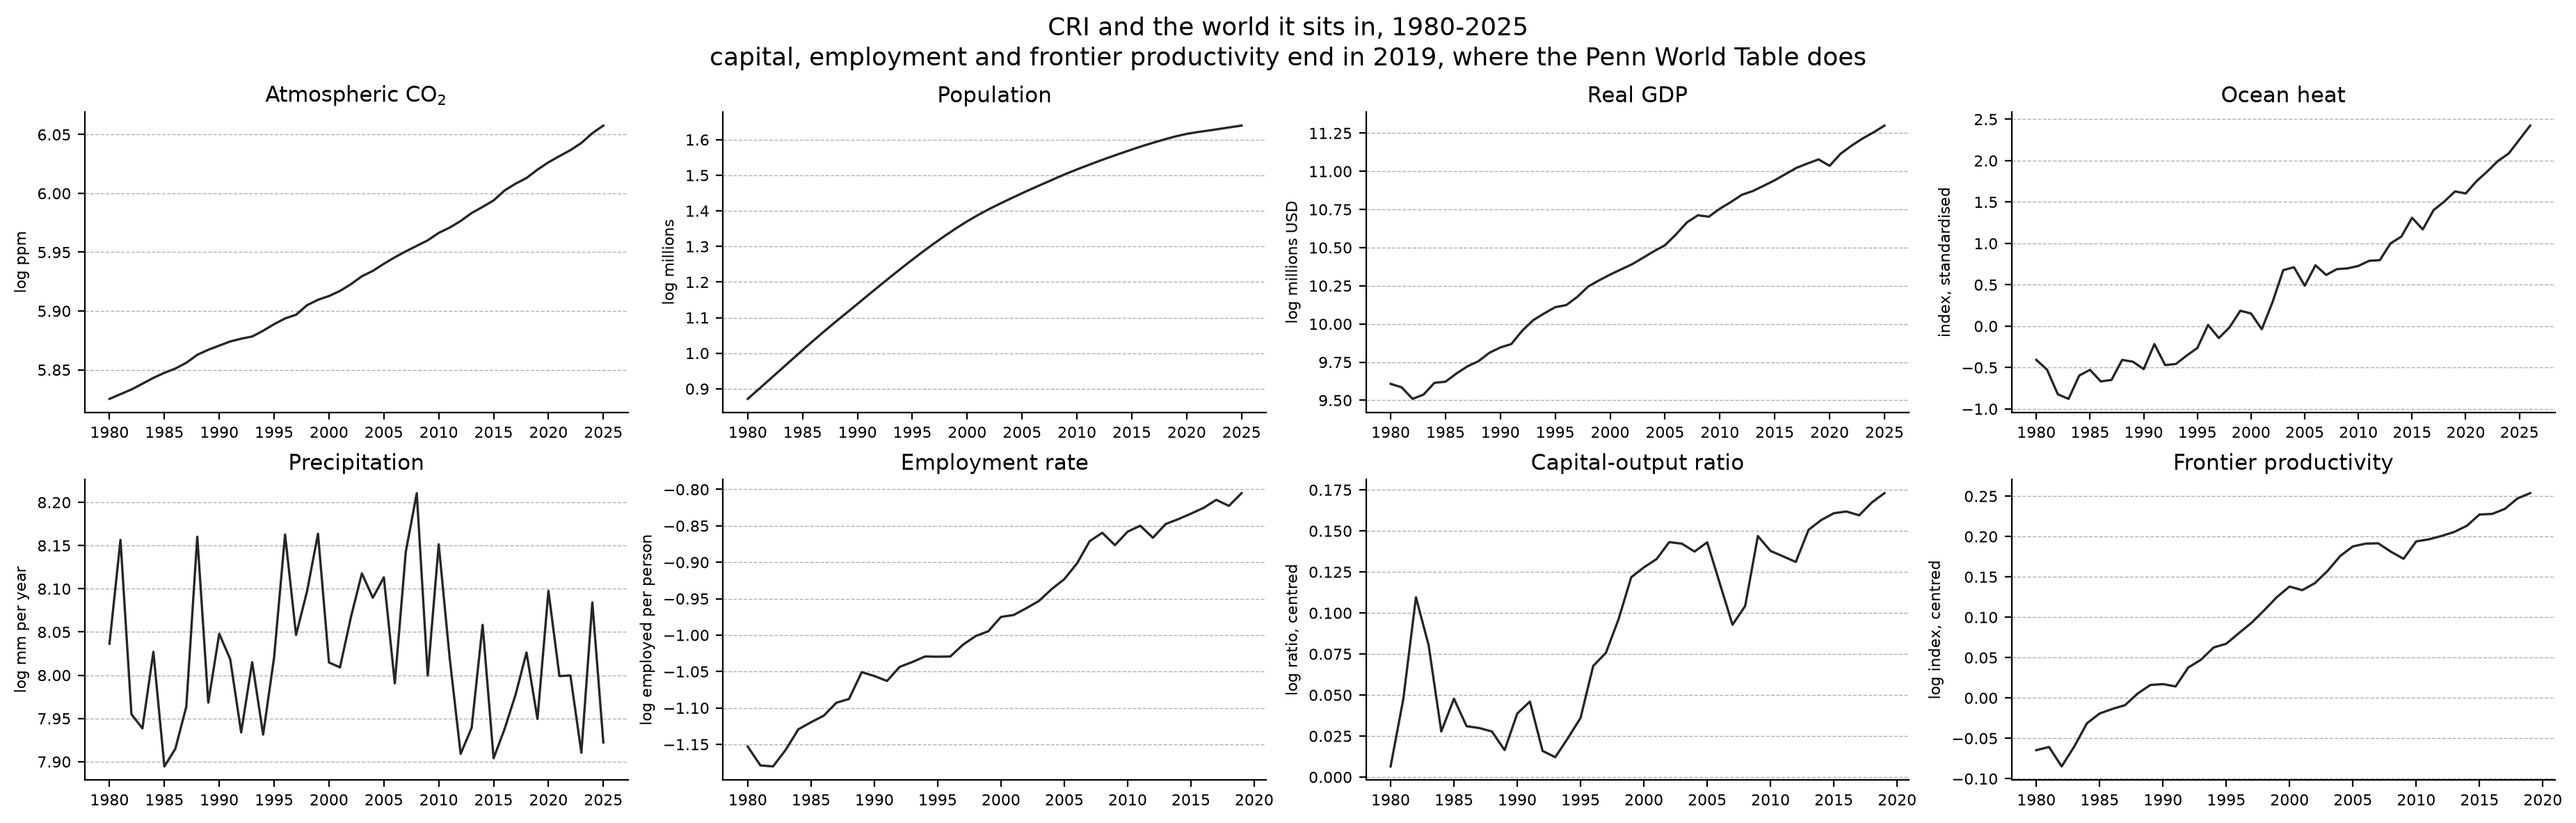

In [7]:
figure, axes = panel_grid(names=OBSERVED, labels=LABELS, units=AXIS_UNITS)

for axis, name in zip(axes, OBSERVED, strict=True):
    series = observed[name].dropna()
    axis.plot(series.index, series.to_numpy(), color="0.15", lw=1.2)

figure.suptitle(
    f"{COUNTRY} and the world it sits in, {FIRST:%Y}-{LAST:%Y}\n"
    "capital, employment and frontier productivity end in 2019, where the Penn World Table does",
    size=13,
)
plt.show()

### Growth accounting

Costa Rica against the frontier over 1980 to 2019, the window the Penn World Table covers. Only
productivity is permanent: capital deepening stops once the capital-output ratio settles, and the
employment rate cannot rise forever, so those two contributions fade over a century.

In [8]:
LABOUR_SHARE = float(home.loc[FIRST:, "labour_share"].mean())
window = home.loc[FIRST:PWT_LAST]
years_covered = (PWT_LAST - FIRST).days / 365.25


def annual_growth(series):
    """Average continuously compounded growth over the window, per year."""
    return (np.log(series.iloc[-1]) - np.log(series.iloc[0])) / years_covered


growth = {name: annual_growth(window[name]) for name in ("pwt_real_gdp", "capital", "employment", "pwt_population")}

# Output per capita decomposes exactly, since the capital and labour weights sum to one:
# (y - n) = a + (1 - theta)(k - n) + theta(l - n).
tfp_growth = growth["pwt_real_gdp"] - (1 - LABOUR_SHARE) * growth["capital"] - LABOUR_SHARE * growth["employment"]
contributions = {
    "capital deepening": (1 - LABOUR_SHARE) * (growth["capital"] - growth["pwt_population"]),
    "employment rate": LABOUR_SHARE * (growth["employment"] - growth["pwt_population"]),
    "productivity": tfp_growth,
}
per_capita = growth["pwt_real_gdp"] - growth["pwt_population"]

decomposition = pd.DataFrame(
    {
        "% per year": {name: value * 100 for name, value in contributions.items()},
        "share": {name: value / per_capita for name, value in contributions.items()},
    }
)
decomposition.loc["total"] = [per_capita * 100, 1.0]
decomposition.round(2)

,% per year,share
capital deepening,0.93,0.52
employment rate,0.51,0.29
productivity,0.33,0.19
total,1.78,1


In [9]:
frontier_growth = float(
    (observed["log_tfp_frontier"].dropna().iloc[-1] - observed["log_tfp_frontier"].dropna().iloc[0])
    / years_covered
)

# Two families of series, each used for what it can support. The national-accounts residuals are
# indices on their own bases, so their difference gives the movement of the gap and not its level;
# `ctfp` is a level at current PPPs with the United States at one, which gives the level and not a
# clean movement. The gap is the second anchoring the first.
gap_movement = (observed["log_tfp_frontier"] - solow_residual(code=COUNTRY, panel=pwt)).dropna()
GAP_1980 = float(-np.log(home.loc[FIRST, "tfp_relative_to_usa"]))
observed_gap = gap_movement - gap_movement.iloc[0] + GAP_1980
gap_drift = float(frontier_growth - tfp_growth)

# Inputs to the capital-output ratio's steady state, which moves as population growth falls.
DEPRECIATION = float(window["depreciation"].mean())
population_growth = observed["log_pop"].dropna().diff().dropna()
POP_GROWTH_MEAN = float(population_growth.mean())
POP_GROWTH_RECENT = float(population_growth.iloc[-5:].mean())

pd.DataFrame(
    [
        ("frontier productivity growth", frontier_growth * 100, "% per year"),
        (f"{COUNTRY} productivity growth", tfp_growth * 100, "% per year"),
        ("gap widening", gap_drift * 100, "% per year"),
        ("depreciation", DEPRECIATION * 100, "% per year"),
        ("population growth, sample mean", POP_GROWTH_MEAN * 100, "% per year"),
        ("population growth, last five years", POP_GROWTH_RECENT * 100, "% per year"),
        ("labour share", LABOUR_SHARE, "share"),
        (f"gap to the frontier, {FIRST:%Y}", GAP_1980, "log points"),
        (f"gap to the frontier, {PWT_LAST:%Y}", observed_gap.loc[PWT_LAST], "log points"),
    ],
    columns=["quantity", "value", "unit"],
).set_index("quantity")

,value,unit
quantity,,
frontier productivity growth,0.8165,% per year
CRI productivity growth,0.33,% per year
gap widening,0.4865,% per year
depreciation,5.064,% per year
"population growth, sample mean",1.707,% per year
"population growth, last five years",0.4658,% per year
labour share,0.5768,share
"gap to the frontier, 1980",0.1362,log points
"gap to the frontier, 2019",0.3262,log points


## The model

A linear Gaussian state space with fifteen latent states, eight observed series and eight
structural innovations. The transition is $x_t = T x_{t-1} + c + R \varepsilon_t$ with
$\varepsilon_t \sim N(0, \Sigma_\varepsilon)$ diagonal, and the measurement is
$y_t = Z x_t + d + \eta_t$ with $\eta_t \sim N(0, \Sigma_\eta)$ diagonal. Each block below gives a
row of $T$ or of $Z$.

Series that end before the sample does are treated as missing and imputed by the filter rather than
truncating the sample, so the Penn World Table variables stop in 2019 while carbon, output,
population and rainfall run to 2025.

### The carbon and warming block

Carbon is measured as doublings above the pre-industrial level, $D_t = \log_2(\mathrm{CO}_2 / 278)$.
It follows a local linear trend whose slope is constant and whose deviation is autoregressive, so
the projected path extrapolates the observed drift and commits to no emissions scenario:

$$
\begin{aligned}
D_t &= D_{t-1} + \mu_D + c_{t-1} \\
c_t &= \rho_D c_{t-1} + \varepsilon^D_t
\end{aligned}
$$

Warming responds to the carbon stock through a one-box thermal model. This is the DICE temperature
block collapsed from two reservoirs to one: DICE-2016R carries an atmospheric layer coupled to a
deep ocean, and forty-six annual observations of a single ocean-heat index do not identify the
second reservoir, so the coupled pair is replaced by a single relaxation toward the equilibrium the
current stock implies,

$$
W_t = \rho_W W_{t-1} + (1 - \rho_W)\, \lambda D_{t-1},
\qquad \rho_W = \exp(-1/h), \quad h = 8 \text{ years}
$$

The fixed point of that recursion is $W = \lambda D$, so $\lambda$ is the transient climate
response in degrees per doubling and carries the AR6 likely range as its prior. The e-folding time
$h$ is held fixed: two smooth monotone series over four decades carry no information separating a
lag from a rescaling, and freeing it trades one against the other.

Realised temperature adds a stationary deviation to the forced path,

$$
\Theta_t = W_t + v_t, \qquad v_t = \rho_v v_{t-1} + \varepsilon^v_t
$$

The two act on different timescales: $W_t$ is the forced response and is slow by construction, and
$v_t$ is internal variability. Only $\Theta_t$ is observed, and damages respond to $\Theta_t$.

### Damages

DICE-2016R writes net output as gross output times a damage factor,
$\Omega(\Theta) = 1/(1 + a_2 \Theta^2)$, with $a_2 = 0.00236$, so that marginal damage near
$2\,^{\circ}\mathrm{C}$ is about 0.9 percent of output per degree. The same multiplicative structure
is kept here and the quadratic is replaced by its log-linear counterpart,

$$
\Omega(\Theta_t) = \exp(-\delta\, \Theta_t)
$$

Damage is a loss of output rather than of productivity, so it enters the output equation with a
coefficient of one rather than scaled by $1/\theta$; this follows DICE and is not a neutral choice.
$\delta$ is a local slope rather than a curvature, so it is informative over the range the forecast
visits, roughly 1 to $2\,^{\circ}\mathrm{C}$, and does not extrapolate beyond it. Its prior sits
above the DICE marginal value and reaches the larger estimates the cross-country panel literature
reports for hot countries.

### Production

Output is Cobb-Douglas with Hicks-neutral productivity and constant returns,

$$
Y_t = A_t K_t^{1-\theta} L_t^{\theta}
$$

Capital is not observed on a comparable basis, but the capital-output ratio is. Substituting
$K_t = (K_t/Y_t) Y_t$ and solving for $\log Y_t$ removes it:

$$
\begin{aligned}
\log Y_t &= \log A_t + (1-\theta)\left(\log \frac{K_t}{Y_t} + \log Y_t\right) + \theta \log L_t \\
\log Y_t &= \frac{1}{\theta}\log A_t + \frac{1-\theta}{\theta}\log \frac{K_t}{Y_t} + \log L_t
\end{aligned}
$$

The labour share appears three times, which is what identifies it: as the scaling on productivity,
as the scaling on the capital-output ratio, and as the ratio between them. Labour splits into
population and the employment rate, $\log L_t = \log N_t + \log(L_t/N_t)$.

### The frontier and the gap

Country productivity is written as distance from a world frontier rather than as a level, since the
level of a national-accounts productivity index means nothing across countries:

$$
\begin{aligned}
\log A_t &= A^F_t - g_t \\
A^F_t &= A^F_{t-1} + \mu_A + \varepsilon^A_t \\
\Delta g_t &= \mu_g + z_{t-1} \\
z_t &= \rho_g z_{t-1} + \varepsilon^g_t
\end{aligned}
$$

The frontier is a random walk with drift, observed through United States productivity, and the gap
is integrated with an autocorrelated difference. Differencing imposes the unit root rather than
leaving a persistence free to find it, which keeps $\rho_g$ away from one, where the stationary
initialisation $\sigma^2/(1-\rho^2)$ diverges. It also leaves $\mu_g$ as the rate of falling behind,
which has a measurable counterpart. Long-run growth in output per worker is
$(\mu_A - \mu_g)/\theta$, the only term that does not fade.

### Factor supply

Population and the employment rate are integrated with autoregressive growth rates that decay to
zero, so both level off rather than compounding forever:

$$
\begin{aligned}
\log N_t &= \log N_{t-1} + n_{t-1}, &\qquad n_t &= \phi_N n_{t-1} + \varepsilon^N_t \\
\log (L_t/N_t) &= \log (L_{t-1}/N_{t-1}) + e_{t-1}, &\qquad e_t &= \phi_E e_{t-1} + \varepsilon^E_t
\end{aligned}
$$

Neither contributes to growth asymptotically, though both contribute over the next few decades. The
growth accounting above gives their share of the last four.

### Capital and its moving target

Balanced growth requires a stationary capital-output ratio: a drifting one drives the capital share
to one or the return on capital to zero. The Solow steady state is
$K/Y = s/(g + n + \delta_K)$, which is constant only if population growth is. Population growth is
falling, so the ratio is stationary around a target that moves with $n_t$. Linearising the steady
state in $n$ gives a slope $\psi = 1/(g + n + \delta_K)$, and writing $\kappa_t$ for the deviation
from the target at average population growth $\bar{n}$:

$$
\begin{aligned}
\kappa_t &= \rho_\kappa \kappa_{t-1} - (1 - \rho_\kappa)\,\psi\,(n_{t-1} - \bar{n})
+ \varepsilon^\kappa_t \\
\log \frac{K_t}{Y_t} &= \bar{\kappa} + \kappa_t
\end{aligned}
$$

As $n_t \to 0$ the target rises by $\psi \bar{n}$ relative to its sample average. Capital deepening
contributes nothing to growth in the limit, since $\kappa_t$ is stationary; the transition path
changes, including its sign.

### Measurement

Writing $y^{\bullet}_t$ for an observed series and reserving unadorned symbols for latent states,
the eight measurement equations are

$$
\begin{aligned}
y^{C}_t &= \log 278 + (\log 2)\, D_t + \eta^{C}_t \\
y^{N}_t &= \log N_t + \eta^{N}_t \\
y^{Y}_t &= c_Y + \frac{1}{\theta}\left(A^F_t - g_t\right) + \log N_t + \log \frac{L_t}{N_t} \\
        &\quad + \frac{1-\theta}{\theta}\left(\bar{\kappa} + \kappa_t\right)
          - \delta\left(W_t + v_t\right) + \eta^{Y}_t \\
y^{T}_t &= a_T + \gamma_T \left(W_t + v_t\right) + \eta^{T}_t \\
y^{P}_t &= a_P + \gamma_P W_t + p_t + \eta^{P}_t \\
y^{E}_t &= \log (L_t/N_t) + \eta^{E}_t \\
y^{K}_t &= \bar{\kappa} + \kappa_t + \eta^{K}_t \\
y^{A}_t &= A^{F}_t + \eta^{A}_t
\end{aligned}
$$

for log carbon, log population, log output, ocean heat, log precipitation, the log employment rate,
the log capital-output ratio and frontier productivity respectively.

Ocean heat is a standardised index, so $\gamma_T$ converts degrees to standard deviations. Warming
is never observed on its own scale, and with both $\gamma_T$ and the warming path free only their
product is identified, so the loading carries a tight prior around a value calibrated against the
carbon-implied path. Precipitation loads on the forced path alone, since a rainfall response to a
one-year temperature anomaly is not what the coefficient measures; its deviation
$p_t = \rho_p p_{t-1} + \varepsilon^p_t$ appears in no other row. $c_Y$ is the unit of the output
series, which nothing else in the identity carries: without it the labour share is the only free
parameter that can reach a level of eleven log points.

### Symbols

Listed in the order the blocks appear above. The code name is the coordinate label the posterior
summaries use.

| Symbol | Code | Meaning |
| --- | --- | --- |
| $\mu_D$ | `drift_co2` | carbon growth, doublings per year |
| $\rho_D$ | `rho[co2]` | persistence of the carbon growth deviation |
| $h$ | fixed | thermal e-folding time, 8 years |
| $\rho_W$ | fixed | $\exp(-1/h)$, the thermal relaxation rate |
| $\lambda$ | `climate_response` | transient climate response, degrees per doubling |
| $\rho_v$ | `rho[temp]` | persistence of internal temperature variability |
| $\delta$ | `damage_elasticity` | output loss in log points per degree |
| $\theta$ | `theta` | labour share |
| $c_Y$ | `gdp_intercept` | unit of the output series |
| $\mu_A$ | `drift_frontier` | frontier productivity growth |
| $\mu_g$ | `drift_gap` | rate of falling behind the frontier |
| $\rho_g$ | `rho[gap_growth]` | persistence of the gap growth deviation |
| $g_0$ | `initial_gap` | gap to the frontier in 1980, at PPP |
| $\phi_N$ | `phi[pop]` | decay of population growth |
| $\phi_E$ | `phi[emp_rate]` | decay of employment rate growth |
| $\psi$ | `ky_slope` | capital-output response to population growth |
| $\bar{\kappa}$ | `ky_mean` | capital-output target at average population growth |
| $\rho_\kappa$ | `rho[ky]` | persistence of the capital-output deviation |
| $\gamma_T$ | `temp_loading` | ocean heat per degree |
| $a_T$ | `obs_intercept[temp]` | ocean heat intercept |
| $\gamma_P$ | `precip_loading` | rainfall response to warming |
| $a_P$ | `obs_intercept[precip]` | rainfall intercept |
| $\rho_p$ | `rho[precip]` | persistence of the rainfall deviation |
| $\varepsilon$ | `sigma_state` | innovation scale, one per shock |
| $\eta$ | `sigma_obs` | measurement error scale, one per series |

In [10]:
climate_economy = ClimateEconomy(population_growth_mean=POP_GROWTH_MEAN)

print(f"{climate_economy.k_states} states, {climate_economy.k_endog} observed, {climate_economy.k_posdef} shocks")

                               Model Requirements                                
                                                                                 
  Variable            Shape   Constraints                            Dimensions  
 ─────────────────────────────────────────────────────────────────────────────── 
  initial_level       (3,)                                     ('level_block',)  
  initial_growth      (2,)                                    ('growth_block',)  
  initial_warming     ()      °C above pre-industrial                      None  
  initial_co2         ()                                                   None  
  initial_gap         ()      log points behind                            None  
  drift_co2           ()                                                   None  
  drift_frontier      ()      log points per year                          None  
  drift_gap           ()      log points behind per year                   None  
  ky_mean             ()                                                   None  
  ky_slope            ()      Positive                                     None  
  gdp_intercept       ()      log millions USD                             None  
  climate_response    ()      °C per doubling                              None  
  theta               ()      labour share, 0 < theta < 1                  None  
  phi                 (2,)    0 < phi < 1                     ('growth_block',)  
  rho                 (5,)    0 < rho < 1                         ('ar_block',)  
  damage_elasticity   ()      log output per °C                            None  
  temp_loading        ()      Positive                                     None  
  precip_loading      ()                                                   None  
  obs_intercept       (2,)                                       ('intercept',)  
  sigma_state         (8,)    Positive                               ('shock',)  
  sigma_obs           (8,)    Positive                      ('observed_state',)  
                                                                                 
   These parameters should be assigned priors inside a PyMC model block before   
                   calling the build_statespace_graph method.                    

15 states, 8 observed, 8 shocks


## Priors

Five priors are elicited from outside this sample. Each keeps a spread wide enough to be moved by
the data.

*The transient climate response* is the warming per doubling of carbon. IPCC AR6 puts its likely
range at 1.4 to 2.2 degrees, which is the interval used here. Forty years of one country's ocean
heat does not pin it, and fixing it at a point would claim knowledge nobody has.

*The damage elasticity* is centred where DICE-2016R puts marginal damage around 2 degrees, with
enough spread to reach the larger values panel studies of hot countries report. The data barely
moves it, so the forecast carries the prior uncertainty forward into the damage calculation
downstream.

*The warming equation is calibrated rather than free.* Warming is never observed. It reaches the
data as a loading times the state, and with both free only the product is identified: a warming path
five times larger and a loading five times smaller fit equally well. The loading is a units
conversion, fitted against a warming path pinned by carbon and given a tight positive prior around
that value.

*The initial gap* is measured, from the Penn World Table's productivity level at current PPPs with
the United States at one. It is the informative half of the pair it forms with the output constant,
which is a unit of measurement and gets a wide prior. The gap enters only the output equation, so a
constant shift in it and a shift in that unit are the same thing to the likelihood.

*The capital-output slope* comes from the Solow steady state, whose log falls with population growth
at a rate of one over the sum of productivity growth, population growth and depreciation. The
interval spans a factor of two either side, since that value rests on three measured rates and on
the model holding exactly.

In [11]:
def calibrate_warming_equation():
    """Fit ocean heat to the warming path the observed carbon stock implies.

    Returns
    -------
    loading : float
        Standard deviations of ocean heat per °C of warming.
    intercept : float
        Where that line sits, in standard deviations.
    residual_sd : float
        Scatter about the line, which is the measurement error the series can support.
    """
    persistence = climate_economy.thermal_persistence
    path = [WARMING_1980]
    for value in doublings.loc[FIRST:].to_numpy()[:-1]:
        path.append(persistence * path[-1] + (1 - persistence) * CLIMATE_RESPONSE * value)
    path = np.array(path)

    series = observed["temp"].to_numpy()
    mask = np.isfinite(series)
    loading, intercept = np.polyfit(path[mask], series[mask], 1)
    residual = series[mask] - (intercept + loading * path[mask])

    return float(loading), float(intercept), float(residual.std())


# Warming in 1980 sits below the equilibrium the carbon stock then implied, by the lag a steadily
# rising forcing sustains: chasing a ramp of `step` a year leaves a shortfall of
# `step * persistence / (1 - persistence)`.
CLIMATE_RESPONSE = 1.8
realised_co2_drift = float((doublings.loc[LAST] - doublings.loc[FIRST]) / SAMPLE_YEARS)
persistence = climate_economy.thermal_persistence
WARMING_1980 = float(
    CLIMATE_RESPONSE * doublings.loc[FIRST]
    - CLIMATE_RESPONSE * realised_co2_drift * persistence / (1 - persistence)
)

TEMP_LOADING, TEMP_INTERCEPT, TEMP_RESIDUAL_SD = calibrate_warming_equation()

pd.DataFrame(
    [
        (f"warming in {FIRST:%Y}, net of the lag", WARMING_1980, "°C"),
        ("ocean heat per °C", TEMP_LOADING, "sd"),
        ("ocean heat intercept", TEMP_INTERCEPT, "sd"),
        ("scatter about the calibrated line", TEMP_RESIDUAL_SD, "sd"),
        ("the same scatter in degrees", TEMP_RESIDUAL_SD / TEMP_LOADING, "°C"),
        ("realised carbon drift", realised_co2_drift, "doublings per year"),
    ],
    columns=["quantity", "value", "unit"],
).set_index("quantity")

,value,unit
quantity,,
"warming in 1980, net of the lag",0.4126,°C
ocean heat per °C,5.316,sd
ocean heat intercept,-3.187,sd
scatter about the calibrated line,0.1782,sd
the same scatter in degrees,0.03351,°C
realised carbon drift,0.007448,doublings per year


In [12]:
anchor_first = observed.loc[FIRST]
log_pop_series = observed["log_pop"].dropna()
log_emp_series = observed["log_emp_rate"].dropna()

# Centre of the elicited labour-share interval, used only to place the two anchors below.
THETA_CENTRE = 0.60

# The output series is in millions of dollars and nothing else in the identity carries that unit.
# Solving the identity at the first observation says where the constant has to sit; the prior on it
# is wide, since a unit of measurement is not something the literature has a view about.
GDP_INTERCEPT_1980 = float(
    anchor_first["log_gdp"]
    - (observed["log_tfp_frontier"].dropna().iloc[0] - GAP_1980) / THETA_CENTRE
    - anchor_first["log_pop"]
    - anchor_first["log_emp_rate"]
)

# The capital-output ratio's steady state is `s / (g + n + delta)`, so its log falls with population
# growth at a rate `1 / (g + n + delta)`. Output per worker grows at the frontier's productivity
# deflated by the labour share.
OUTPUT_PER_WORKER_GROWTH = frontier_growth / THETA_CENTRE
KY_SLOPE_CENTRE = 1.0 / (OUTPUT_PER_WORKER_GROWTH + POP_GROWTH_RECENT + DEPRECIATION)

ANCHORS = {
    "level": np.array(
        [observed["log_tfp_frontier"].dropna().iloc[0], anchor_first["log_pop"], anchor_first["log_emp_rate"]]
    ),
    "growth": np.array(
        [
            (log_pop_series.iloc[5] - log_pop_series.iloc[0]) / 5,
            (log_emp_series.iloc[5] - log_emp_series.iloc[0]) / 5,
        ]
    ),
    "gap": GAP_1980,
    "gdp_intercept": GDP_INTERCEPT_1980,
}

pd.DataFrame(
    [
        (f"gap to the frontier, {FIRST:%Y}", ANCHORS["gap"], "log points"),
        (f"output constant, {FIRST:%Y}", ANCHORS["gdp_intercept"], "log millions USD"),
        ("output per worker growth", OUTPUT_PER_WORKER_GROWTH * 100, "% per year"),
        ("capital-output slope on population growth", KY_SLOPE_CENTRE, "log points per unit"),
        ("target rise as population growth reaches zero", KY_SLOPE_CENTRE * POP_GROWTH_RECENT, "log points"),
    ],
    columns=["anchor", "value", "unit"],
).set_index("anchor")

,value,unit
anchor,,
"gap to the frontier, 1980",0.1362,log points
"output constant, 1980",10.22,log millions USD
output per worker growth,1.361,% per year
capital-output slope on population growth,14.51,log points per unit
target rise as population growth reaches zero,0.0676,log points


In [13]:
# Year-to-year variation in each growth rate, and measurement error in each series. The temperature
# deviation is in °C, and the ocean heat series carries roughly six standard deviations to the
# degree, so the scatter it shows corresponds to a few hundredths of a degree. Ocean heat's
# measurement error reaches down to a tenth of the series scatter, so the deviation state and the
# error term are not forced to split it on the prior's terms.
STATE_SCALES = {
    "co2": (0.0005, 0.005),
    "frontier": (0.002, 0.020),
    "pop": (0.0002, 0.002),
    "emp_rate": (0.001, 0.010),
    "gap": (0.005, 0.040),
    "ky": (0.005, 0.040),
    "precip": (0.020, 0.200),
    "temp": (0.005, 0.050),
}
OBS_SCALES = {
    "log_co2": (0.0001, 0.002),
    "log_pop": (0.00001, 0.001),
    "log_gdp": (0.002, 0.020),
    "temp": (0.02, 0.30),
    "precip": (0.020, 0.150),
    "log_emp_rate": (0.002, 0.030),
    "log_ky": (0.002, 0.030),
    "log_tfp_frontier": (0.002, 0.030),
}

# Maximum entropy subject to the stated interval: the least committal member of the family that
# respects it. Gamma keeps the scales off zero, where a variance decomposition has no gradient.
state_priors = {
    name: pz.maxent(pz.Gamma(), lower=low, upper=high, mass=0.90) for name, (low, high) in STATE_SCALES.items()
}
obs_priors = {
    name: pz.maxent(pz.Gamma(), lower=low, upper=high, mass=0.90) for name, (low, high) in OBS_SCALES.items()
}

# The interval each prior was fitted to is kept beside it, so the figure below can mark what was
# asked for against what the maximum entropy fit delivered.
ELICITED_INTERVALS = {
    # IPCC AR6 likely range for the transient climate response.
    "climate_response": (1.4, 2.2),
    # The Penn World Table reports 0.577 and holds it near constant, which is an imputation.
    # Corrections for self-employment income put labour shares higher; the interval spans both.
    "theta": (0.50, 0.70),
    "phi[pop]": (0.93, 0.998),
    "phi[emp_rate]": (0.90, 0.995),
    "temp_loading": (TEMP_LOADING - 0.8, TEMP_LOADING + 0.8),
    # The Solow value rests on three measured rates and on the model holding exactly, so the
    # interval spans roughly a factor of two either side of it. The sign is not in question.
    "ky_slope": (KY_SLOPE_CENTRE / 2, KY_SLOPE_CENTRE * 1.6),
}
ELICITED_FAMILIES = {
    "climate_response": pz.Gamma(),
    "theta": pz.Beta(),
    "phi[pop]": pz.Beta(),
    "phi[emp_rate]": pz.Beta(),
    "temp_loading": pz.Gamma(),
    "ky_slope": pz.Gamma(),
}

elicited = {
    name: pz.maxent(ELICITED_FAMILIES[name], lower=low, upper=high, mass=0.90)
    for name, (low, high) in ELICITED_INTERVALS.items()
}
response_prior = elicited["climate_response"]
theta_prior = elicited["theta"]
phi_pop_prior = elicited["phi[pop]"]
phi_emp_prior = elicited["phi[emp_rate]"]
loading_prior = elicited["temp_loading"]
ky_slope_prior = elicited["ky_slope"]

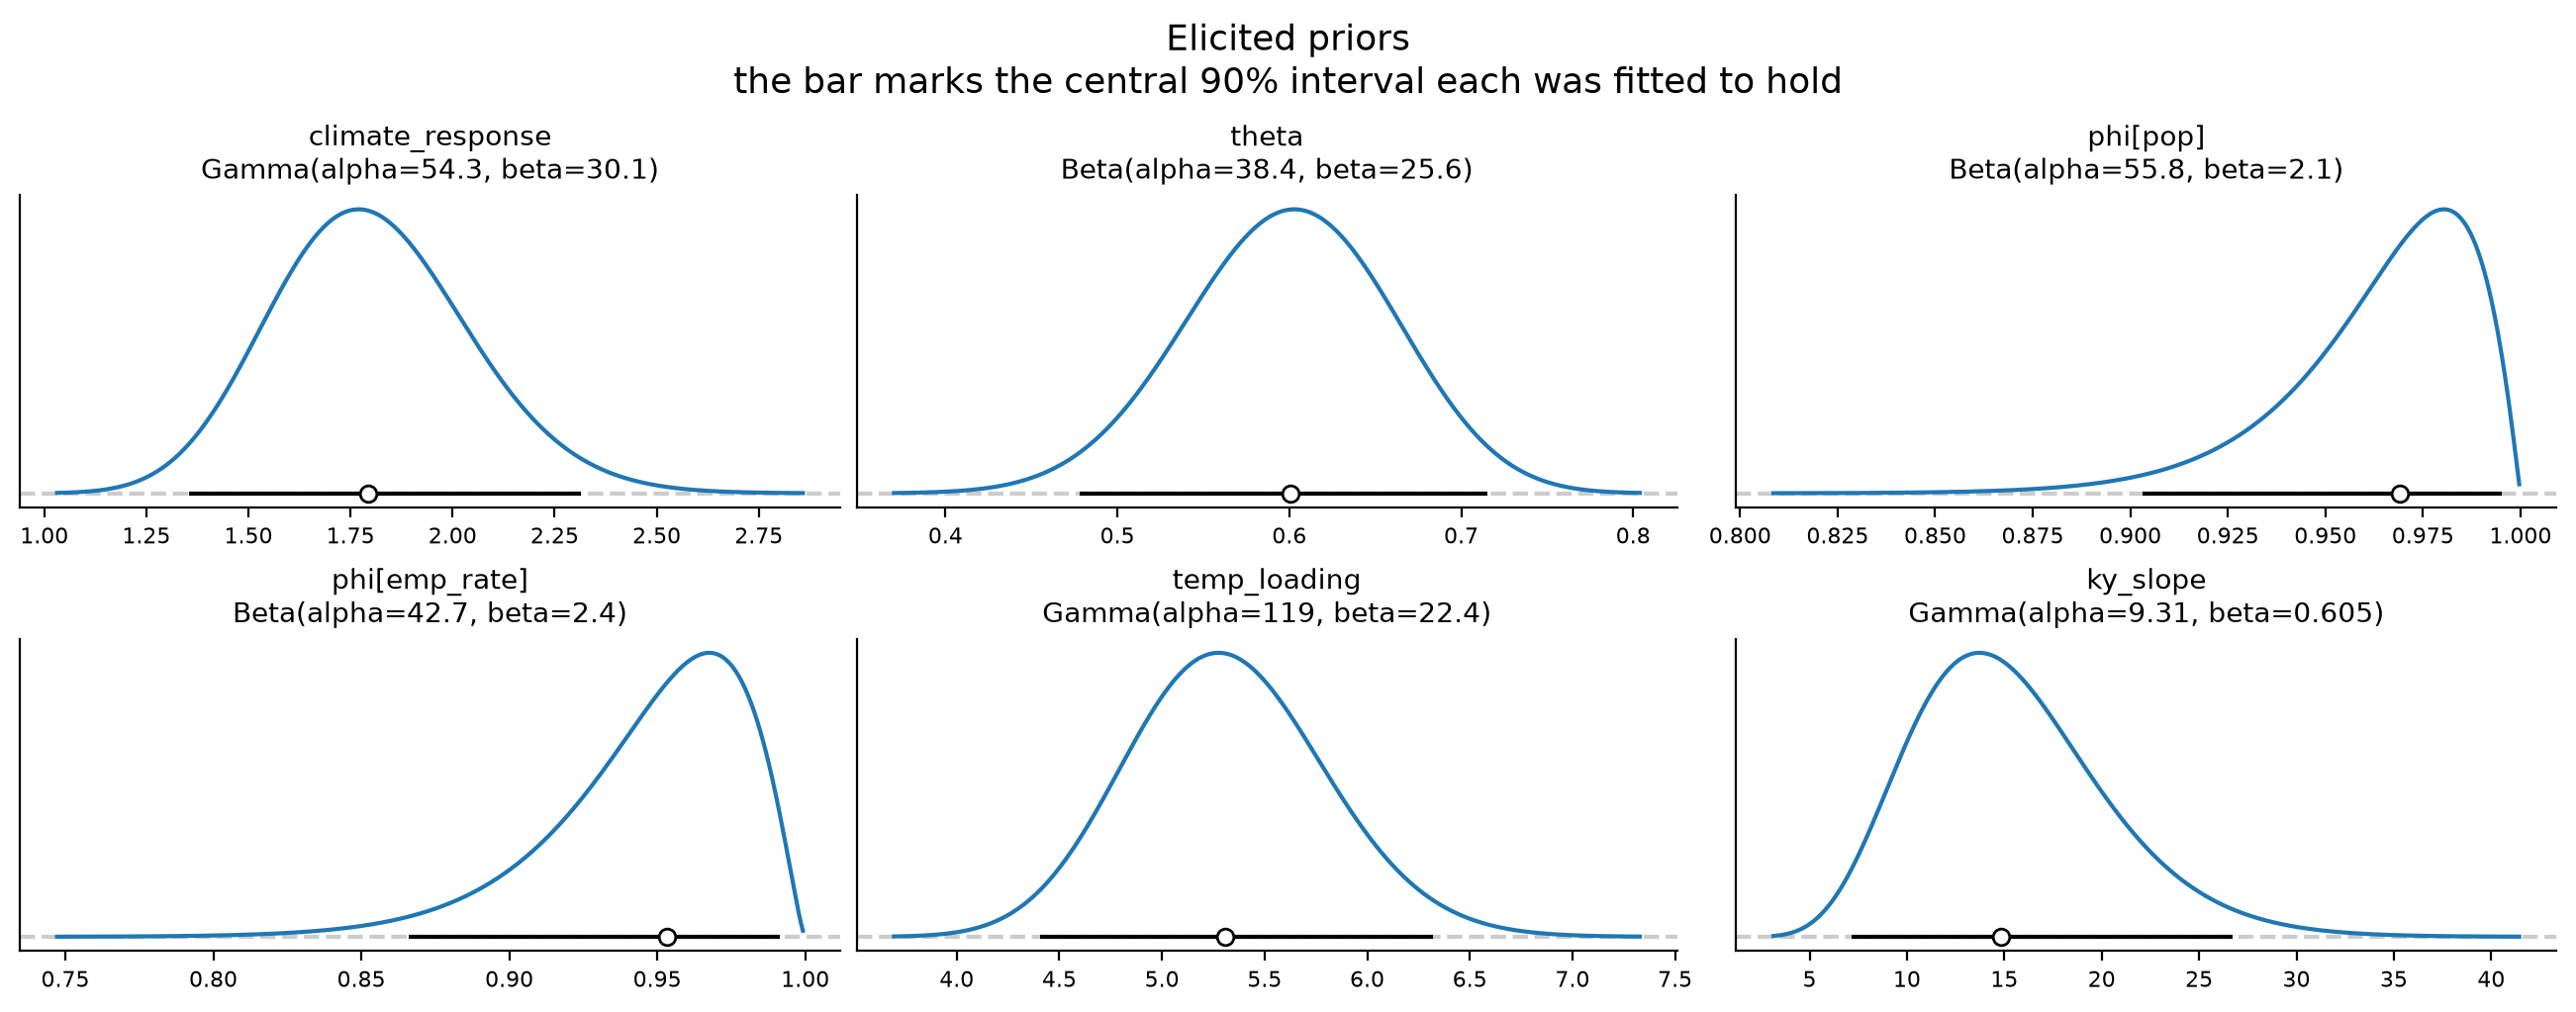

In [14]:
figure, axes = panel_grid(names=list(elicited), n_cols=3, height=2.5, width=4.3)

for axis, (name, prior) in zip(axes, elicited.items(), strict=True):
    with warnings.catch_warnings(action="ignore"):
        prior.plot_pdf(ax=axis, interval="eti", levels=[0.05, 0.95], pointinterval=True, legend="title")

    axis.set_title(f"{name}\n{axis.get_title()}", size=10)
    axis.set_ylabel("")
    axis.set_yticks([])

figure.suptitle(
    "Elicited priors\n"
    "the bar marks the central 90% interval each was fitted to hold",
    size=13,
)
plt.show()

In [15]:
with pm.Model(coords=climate_economy.coords) as model:
    pm.Normal("initial_level", mu=ANCHORS["level"], sigma=np.array([0.05, 0.1, 0.1]), dims=["level_block"])
    pm.Normal("initial_growth", mu=ANCHORS["growth"], sigma=0.004, dims=["growth_block"])
    pm.Normal("initial_warming", mu=WARMING_1980, sigma=0.05)
    pm.Normal("initial_co2", mu=float(doublings.loc[FIRST]), sigma=0.05)

    # The gap is measured, at current PPPs, with the level uncertainty a PPP conversion carries.
    # It is collinear with the output constant below, so it has to be the informative one.
    pm.Normal("initial_gap", mu=ANCHORS["gap"], sigma=0.20)

    pm.Normal("drift_co2", mu=realised_co2_drift, sigma=0.002)
    pm.Normal("drift_frontier", mu=frontier_growth, sigma=0.004)
    pm.Normal("drift_gap", mu=gap_drift, sigma=0.006)
    pm.Normal("ky_mean", mu=0.0, sigma=0.05)
    ky_slope_prior.to_pymc(name="ky_slope")
    pm.Normal("gdp_intercept", mu=ANCHORS["gdp_intercept"], sigma=1.0)

    response_prior.to_pymc(name="climate_response")
    theta_prior.to_pymc(name="theta")
    pm.Deterministic(
        "phi",
        pt.stack([phi_pop_prior.to_pymc(name="phi_pop"), phi_emp_prior.to_pymc(name="phi_emp")]),
        dims=["growth_block"],
    )
    pm.Beta("rho", alpha=2.0, beta=2.0, dims=["ar_block"])

    # DICE-2016R puts marginal damage near 0.009 per °C around 2 °C of warming; panel estimates for
    # hot countries run several times that. The prior spans both and admits zero.
    pm.Normal("damage_elasticity", mu=0.02, sigma=0.04)
    loading_prior.to_pymc(name="temp_loading")
    pm.Normal("precip_loading", mu=0.0, sigma=0.3)
    pm.Normal(
        "obs_intercept",
        mu=np.array([TEMP_INTERCEPT, float(observed["precip"].mean())]),
        sigma=np.array([0.4, 0.3]),
        dims=["intercept"],
    )

    pm.Deterministic(
        "sigma_state",
        pt.stack([state_priors[name].to_pymc(name=f"sigma_state_{name}") for name in SHOCKS]),
        dims=["shock"],
    )
    pm.Deterministic(
        "sigma_obs",
        pt.stack([obs_priors[name].to_pymc(name=f"sigma_obs_{name}") for name in OBSERVED]),
        dims=["observed_state"],
    )

    climate_economy.build_statespace_graph(observed)
    prior = pm.sample_prior_predictive(draws=500, random_seed=0)

print(f"{len(model.free_RVs)} free parameters")

Sampling: [climate_response, damage_elasticity, drift_co2, drift_frontier, drift_gap, gdp_intercept, initial_co2, initial_gap, initial_growth, initial_level, initial_warming, ky_mean, ky_slope, obs, obs_intercept, phi_emp, phi_pop, precip_loading, rho, sigma_obs_log_co2, sigma_obs_log_emp_rate, sigma_obs_log_gdp, sigma_obs_log_ky, sigma_obs_log_pop, sigma_obs_log_tfp_frontier, sigma_obs_precip, sigma_obs_temp, sigma_state_co2, sigma_state_emp_rate, sigma_state_frontier, sigma_state_gap, sigma_state_ky, sigma_state_pop, sigma_state_precip, sigma_state_temp, temp_loading, theta]


36 free parameters


Sampling: [filtered_prior, filtered_prior_observed, predicted_prior, predicted_prior_observed, smoothed_prior, smoothed_prior_observed]


Output()

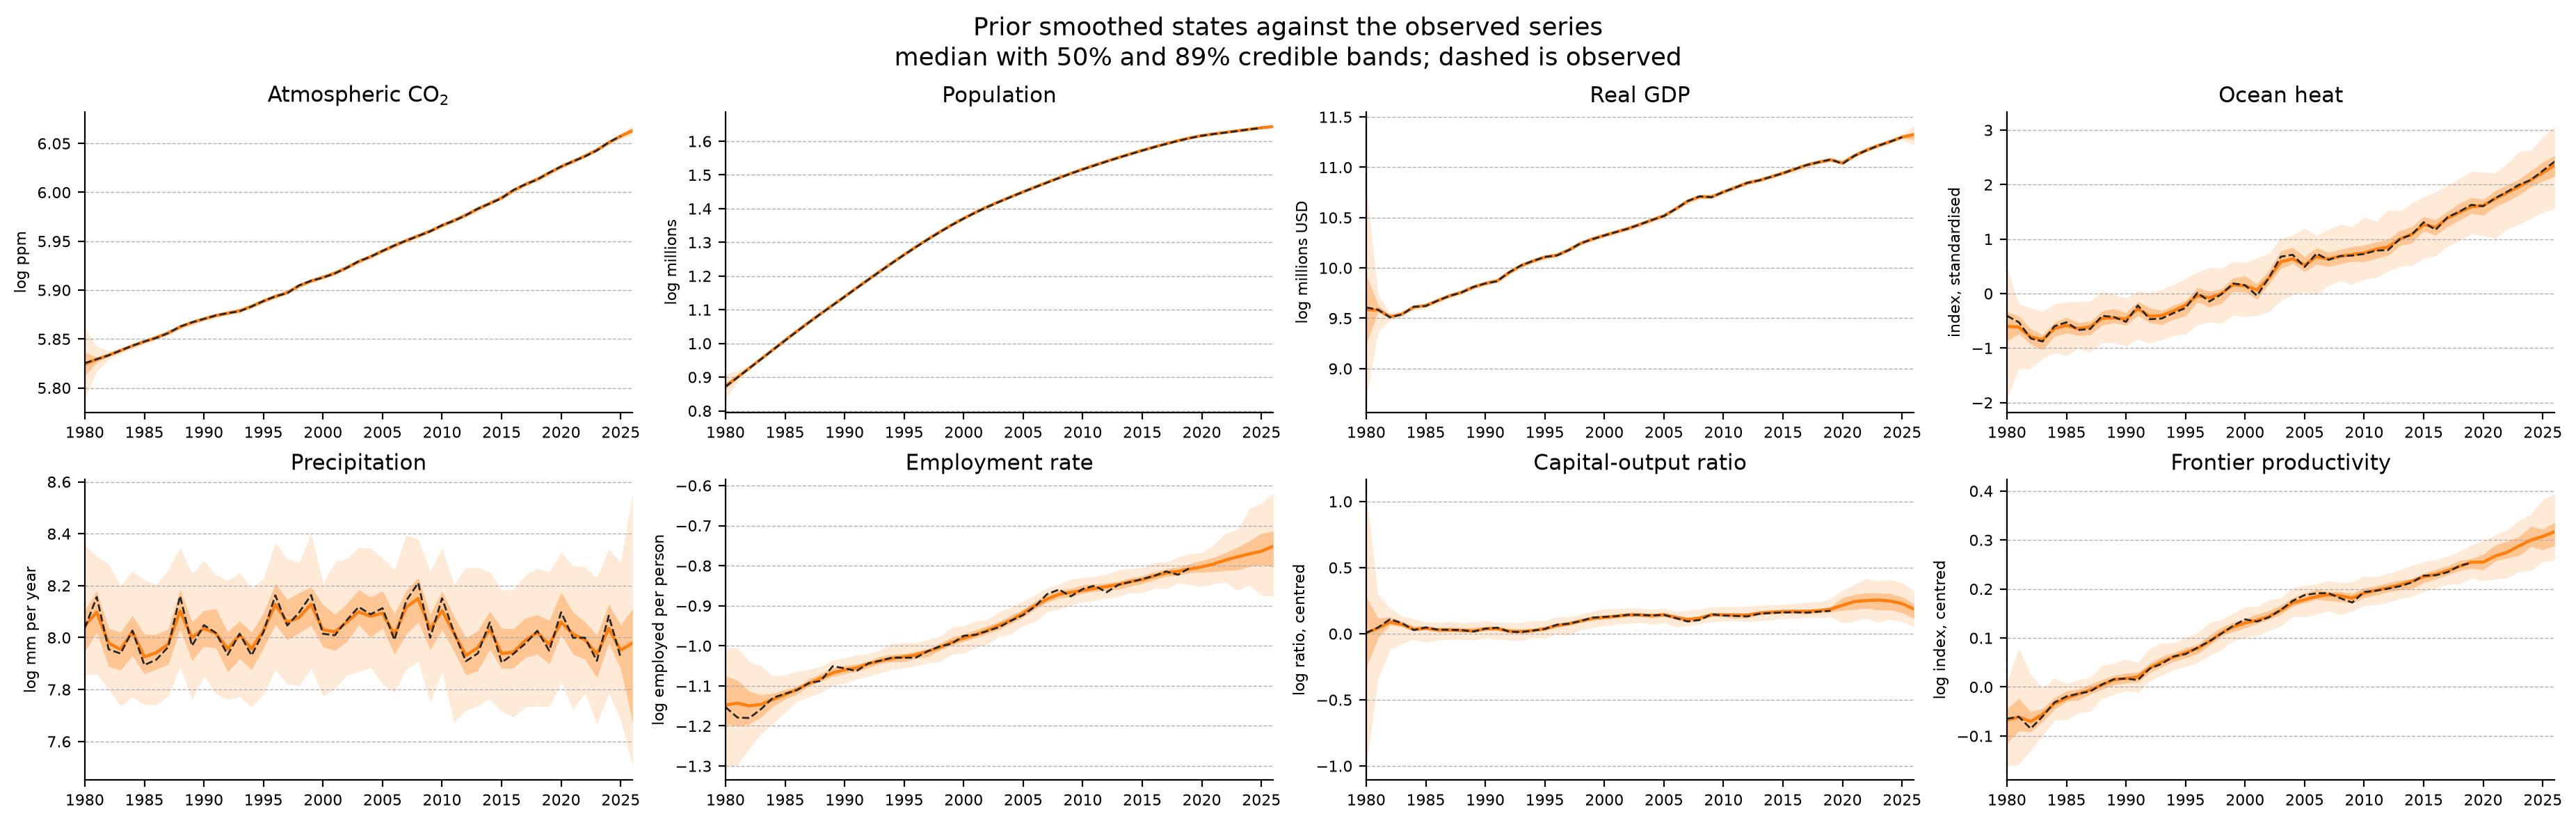

In [16]:
# A masked observation has its design row zeroed, so `obs` carries no information there and a draw
# from it is not a prediction. The smoother states what the model infers each series was.
prior_conditional = climate_economy.sample_conditional_prior(prior, random_seed=0)
smoothed_prior = prior_conditional["/posterior_predictive"]["smoothed_prior_observed"]

figure, axes = panel_grid(names=OBSERVED, labels=LABELS, units=AXIS_UNITS)

for axis, name in zip(axes, OBSERVED, strict=True):
    plot_fan(
        draws=smoothed_prior.sel(observed_state=name),
        axis=axis,
        observed=observed[name],
        color="tab:orange",
    )

figure.suptitle(
    "Prior smoothed states against the observed series\n"
    f"median with {BAND_PROBS[0]:.0%} and {BAND_PROBS[1]:.0%} credible bands; dashed is observed",
    size=13,
)
plt.show()

## Fitting

In [17]:
IDATA_PATH = IDATA_DIR / "climate_economy_cr.idata"

PARAMS = [
    "climate_response",
    "theta",
    "damage_elasticity",
    "temp_loading",
    "precip_loading",
    "drift_frontier",
    "drift_gap",
    "initial_gap",
    "gdp_intercept",
    "ky_mean",
    "ky_slope",
    "phi",
    "rho",
    "sigma_state",
    "sigma_obs",
]

if IDATA_PATH.exists():
    idata = az.from_netcdf(IDATA_PATH)
else:
    with model:
        idata = pm.sample(chains=6, cores=6, tune=1000, draws=1000, target_accept=0.95, random_seed=0)
    IDATA_DIR.mkdir(parents=True, exist_ok=True)
    idata.to_netcdf(IDATA_PATH)

idata["prior"] = prior["prior"]
posterior = idata.posterior.to_dataset()
prior_draws = idata.prior.to_dataset()

kept = posterior.sizes["chain"] * posterior.sizes["draw"]
print(f"divergences {int(idata.sample_stats['diverging'].sum())} of {kept} draws")

az.summary(idata, var_names=PARAMS)

NUTS[nutpie]: [initial_level, initial_growth, initial_warming, initial_co2, initial_gap, drift_co2, drift_frontier, drift_gap, ky_mean, ky_slope, gdp_intercept, climate_response, theta, phi_pop, phi_emp, rho, damage_elasticity, temp_loading, precip_loading, obs_intercept, sigma_state_co2, sigma_state_frontier, sigma_state_pop, sigma_state_emp_rate, sigma_state_gap, sigma_state_ky, sigma_state_precip, sigma_state_temp, sigma_obs_log_co2, sigma_obs_log_pop, sigma_obs_log_gdp, sigma_obs_temp, sigma_obs_precip, sigma_obs_log_emp_rate, sigma_obs_log_ky, sigma_obs_log_tfp_frontier]


/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/site-packages/nutpie/compile_pymc.py:965: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  return inner(x, *_shared_tuple)


Output()

divergences 4 of 6000 draws


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
climate_response,1.756,0.113,1.6,1.9,1948,2659,1.00,0.0026,0.0018
theta,0.664,0.054,0.58,0.75,3425,3781,1.00,0.00093,0.00064
damage_elasticity,0.016,0.0402,-0.048,0.082,6411,4249,1.00,0.0005,0.00035
temp_loading,5.76,0.43,5.1,6.5,1525,2069,1.00,0.011,0.0076
precip_loading,-0.052,0.116,-0.23,0.13,2425,2590,1.00,0.0024,0.002
drift_frontier,0.00823,0.00173,0.0055,0.011,10013,3908,1.00,1.7e-05,1.2e-05
drift_gap,0.00384,0.0042,-0.0027,0.011,9697,4629,1.00,4.3e-05,3.2e-05
initial_gap,0.14,0.19,-0.15,0.44,497,750,1.00,0.0083,0.0056
gdp_intercept,10.22,0.28,9.8,11,498,772,1.00,0.013,0.0085
ky_mean,0.1153,0.0141,0.096,0.14,4257,3336,1.00,0.00025,0.00041


In [18]:
def each_element(array):
    """Yield a label and a selector for every entry of a possibly vector-valued variable.

    Parameters
    ----------
    array : DataArray
        A posterior or prior variable carrying ``chain`` and ``draw``, and at most one other
        dimension.

    Yields
    ------
    label : str
        The variable name, subscripted by coordinate where there is one.
    selector : dict mapping str to object
        Passed to ``sel`` to pick that entry out.
    """
    extra = [dim for dim in array.dims if dim not in ("chain", "draw")]
    if not extra:
        yield array.name, {}
        return

    for value in array.coords[extra[0]].values:
        yield f"{array.name}[{value}]", {extra[0]: value}


def prior_shrinkage(*, idata, var_names):
    """Posterior spread as a fraction of prior spread, one row per parameter.

    Parameters
    ----------
    idata : InferenceData
        Carrying both a ``prior`` and a ``posterior`` group.
    var_names : list of str
        Parameters to report, vector-valued ones expanded to one row per coordinate.

    Returns
    -------
    DataFrame
        Prior standard deviation, posterior standard deviation and their ratio, sorted so the
        parameters the data moved most come first. A ratio near one means the data said nothing
        the prior had not already said.
    """
    posterior, prior = idata.posterior.to_dataset(), idata.prior.to_dataset()
    rows = {}
    for name in var_names:
        for label, selector in each_element(posterior[name]):
            rows[label] = {
                "prior sd": float(prior[name].sel(selector).std()),
                "posterior sd": float(posterior[name].sel(selector).std()),
            }

    frame = pd.DataFrame(rows).T
    frame["retained"] = frame["posterior sd"] / frame["prior sd"]

    return frame.sort_values("retained")

Posterior spread as a fraction of prior spread. A ratio near one means the data did not move the
parameter. Warming over these decades is a smooth ramp and every other channel in the model supplies
a smooth ramp too, which leaves the damage elasticity where its prior put it.

In [19]:
ELICITED = [
    "climate_response",
    "theta",
    "damage_elasticity",
    "temp_loading",
    "precip_loading",
    "drift_frontier",
    "drift_gap",
    "initial_gap",
    "ky_slope",
]

shrinkage = prior_shrinkage(idata=idata, var_names=ELICITED)
shrinkage.round(3)

,prior sd,posterior sd,retained
ky_slope,5.082,1.697,0.334
precip_loading,0.309,0.116,0.376
drift_frontier,0.004,0.002,0.447
climate_response,0.237,0.113,0.475
drift_gap,0.006,0.004,0.665
temp_loading,0.509,0.429,0.842
theta,0.057,0.054,0.944
initial_gap,0.193,0.186,0.96
damage_elasticity,0.041,0.04,0.982


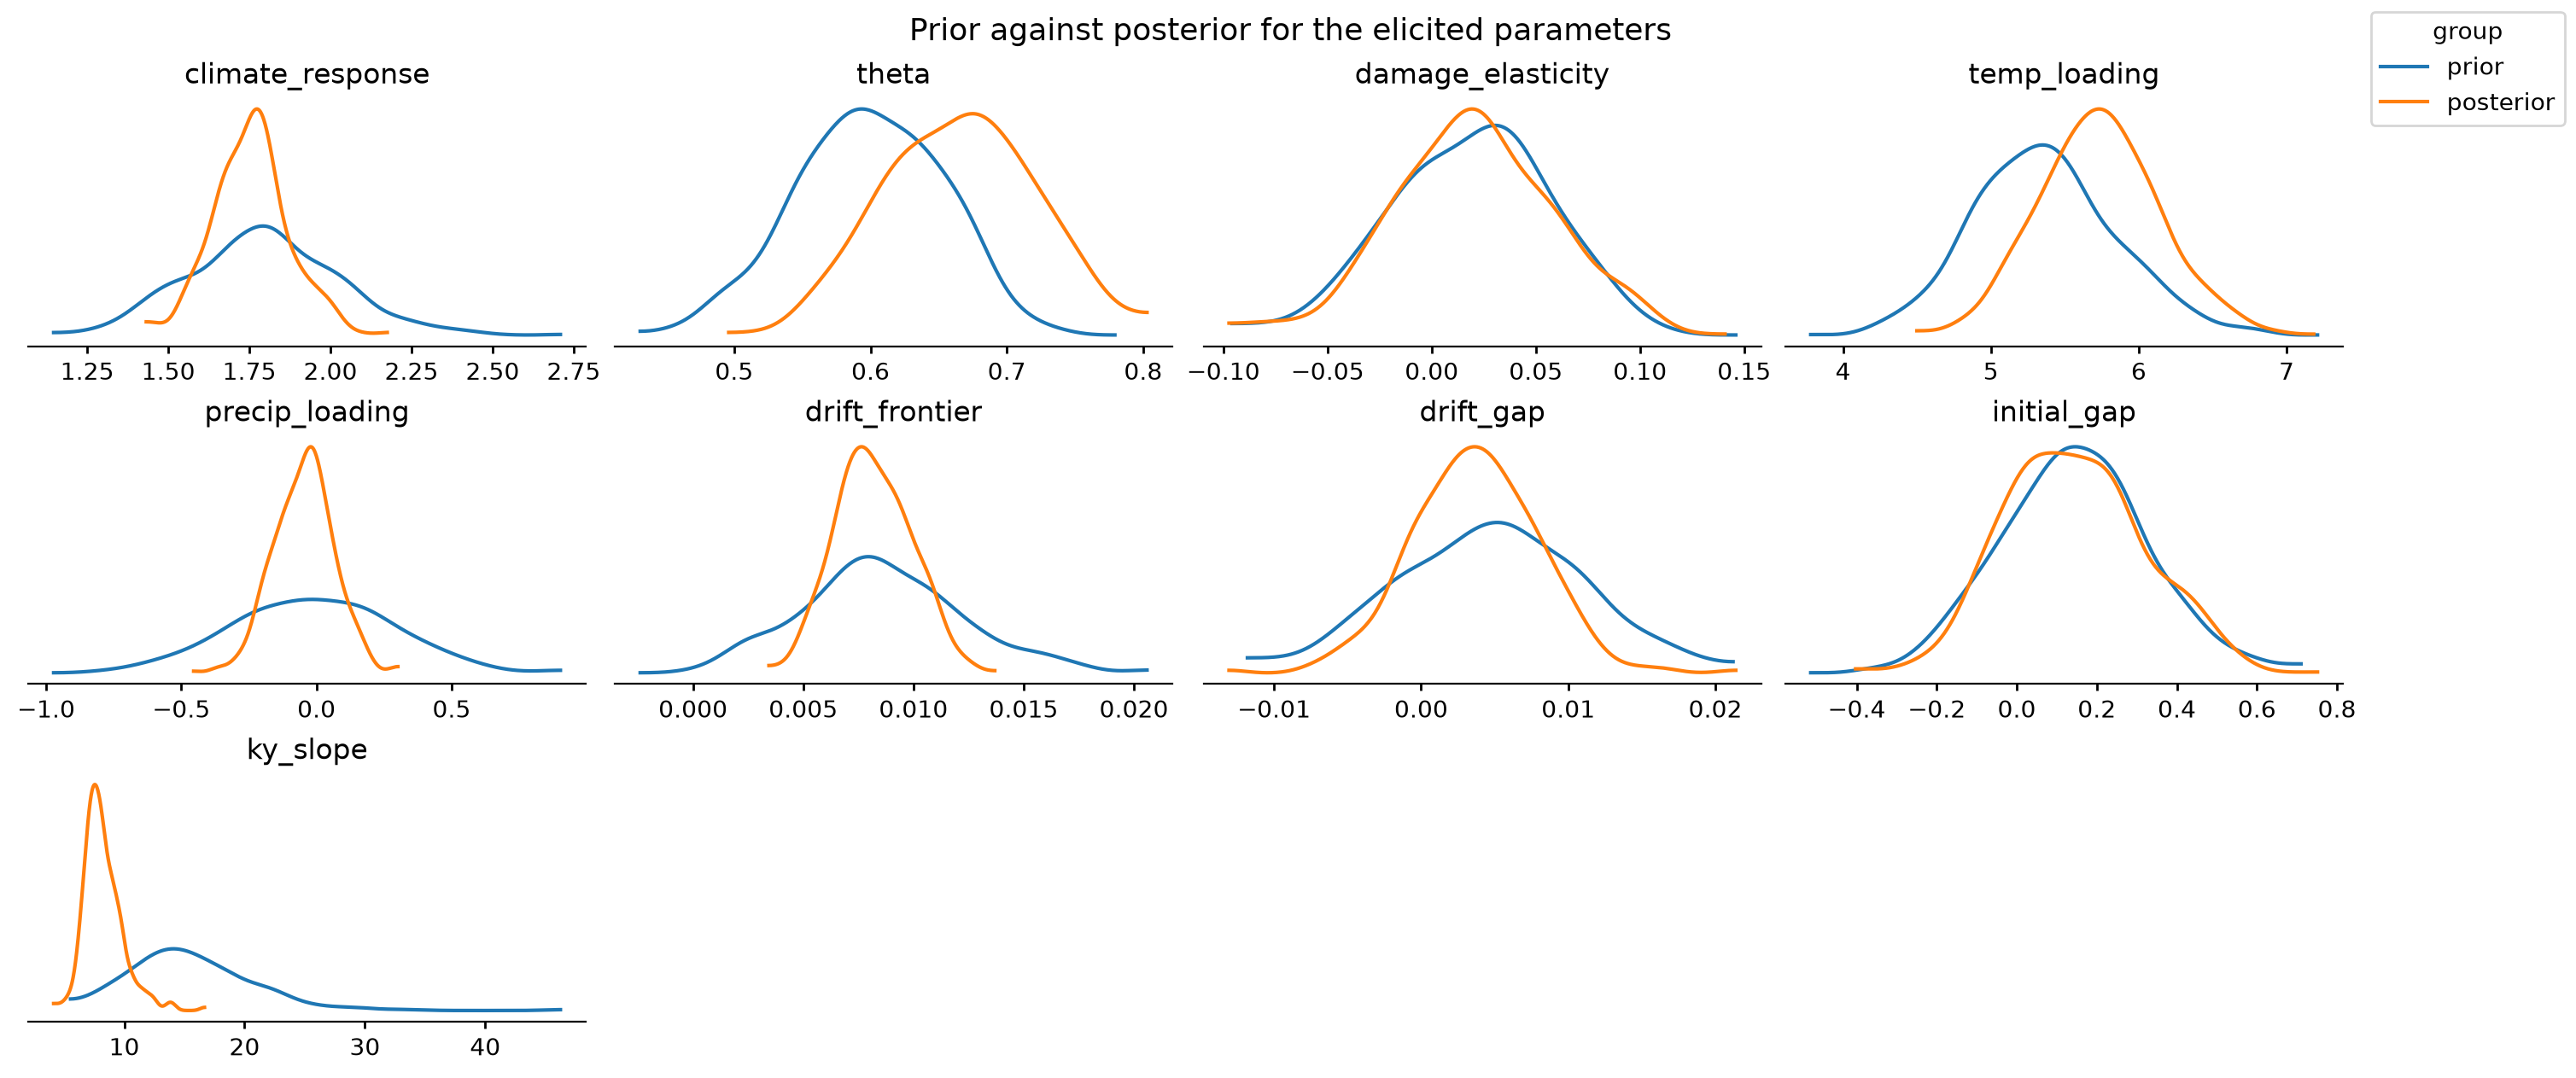

In [20]:
az.plot_prior_posterior(
    idata,
    var_names=ELICITED,
    figure_kwargs={"figsize": (15, 6.2), "dpi": 200},
)
plt.suptitle("Prior against posterior for the elicited parameters", size=13)
plt.show()

## In-sample fit

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

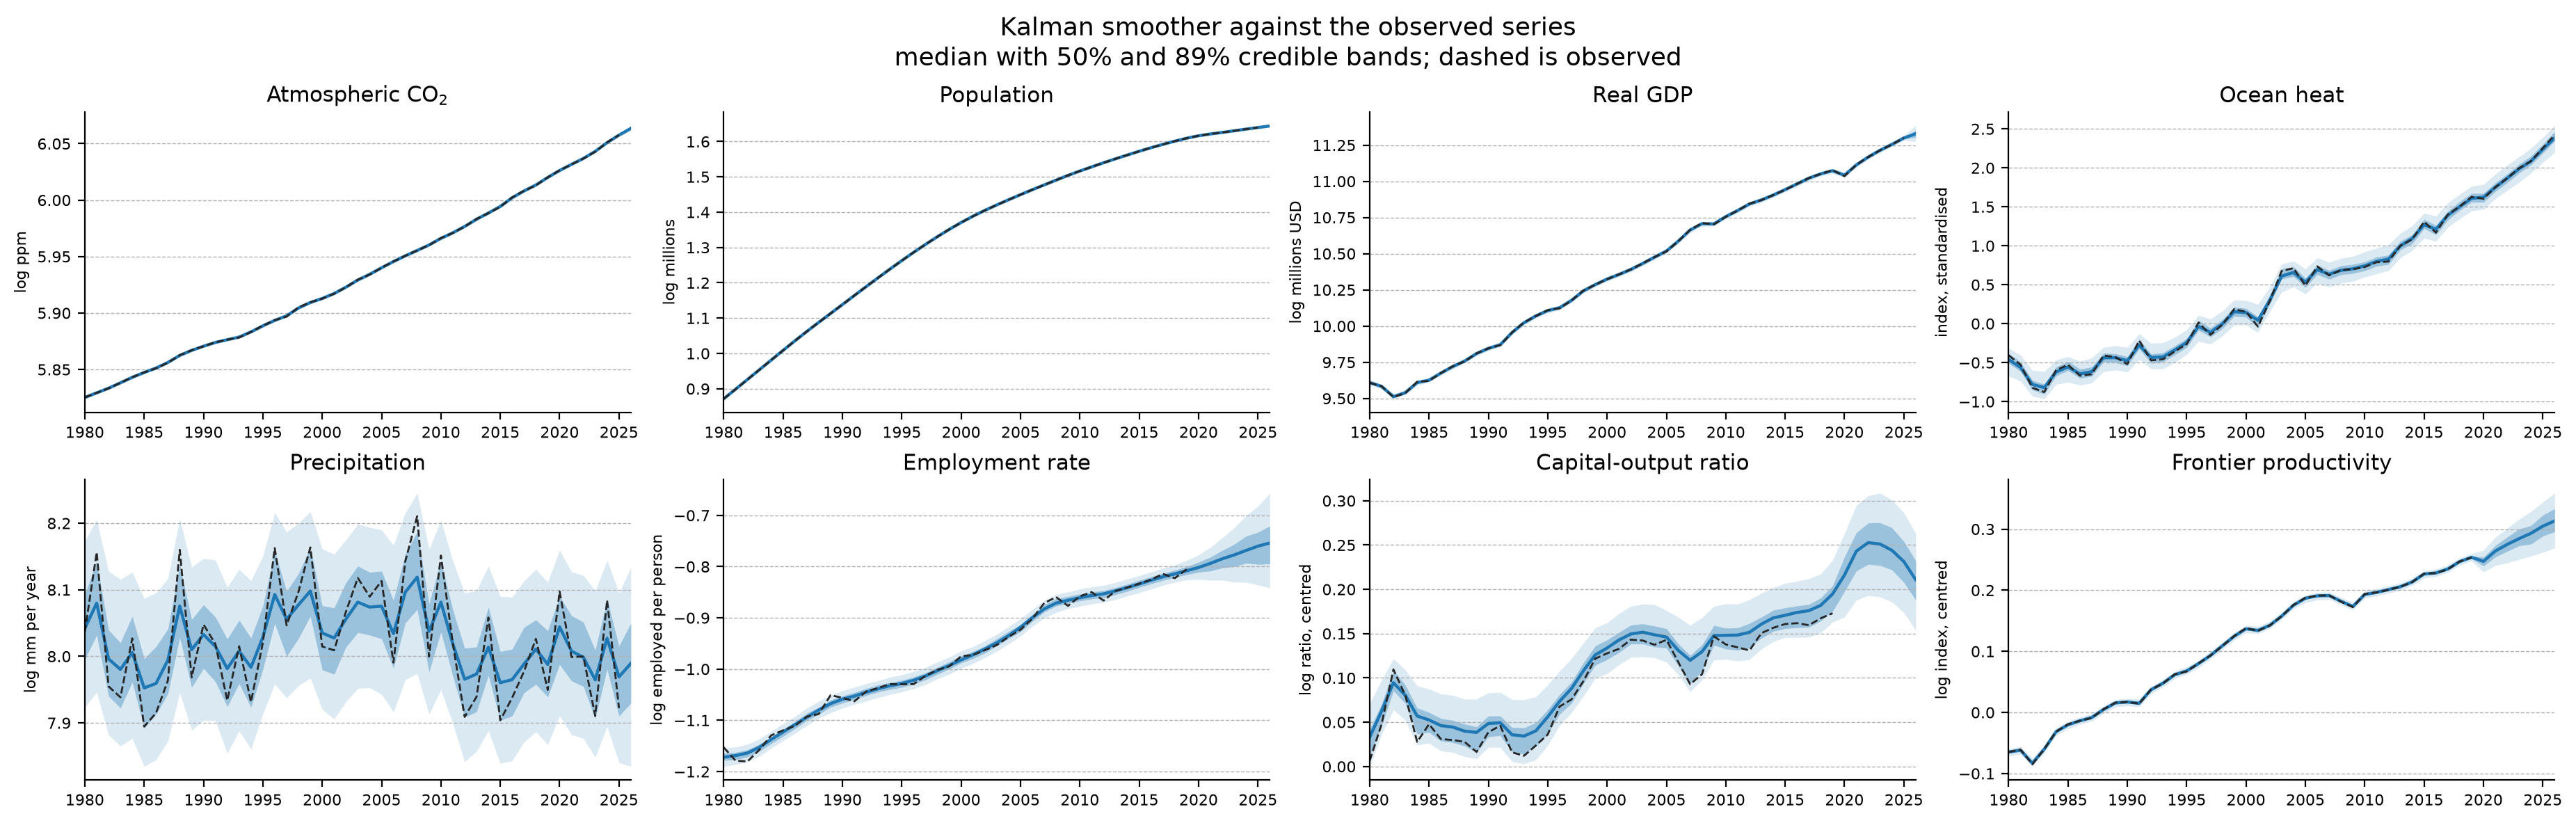

In [21]:
smoothed = climate_economy.sample_conditional_posterior(idata, random_seed=0)
smoothed_observed = smoothed.smoothed_posterior_observed
smoothed_latent = smoothed.smoothed_posterior

figure, axes = panel_grid(names=OBSERVED, labels=LABELS, units=AXIS_UNITS)

for axis, name in zip(axes, OBSERVED, strict=True):
    plot_fan(draws=smoothed_observed.sel(observed_state=name), axis=axis, observed=observed[name])

figure.suptitle(
    "Kalman smoother against the observed series\n"
    f"median with {BAND_PROBS[0]:.0%} and {BAND_PROBS[1]:.0%} credible bands; dashed is observed",
    size=13,
)
plt.show()

## Forecast

Balanced growth per capita is the frontier's productivity growth less the rate of falling behind,
divided by the labour share. Capital deepening and the employment rate contribute over the next few
decades and nothing asymptotically.

In [22]:
# The filter runs to the last date any series is observed, which is a year past the last GDP
# observation. The forecast continues from there; the multiples below are still taken against the
# last observed GDP level.
DATA_END = observed.index.max()
FORECAST_END = pd.Timestamp("2100-01-01")
FORECAST_PERIODS = FORECAST_END.year - DATA_END.year
TARGET_YEARS = [2035, 2050, 2075, FORECAST_END.year]
HORIZONS = [year - DATA_END.year for year in TARGET_YEARS]


def horizon_table(*, draws, base, horizons, prob=0.89):
    """Summarise a log-scale forecast as multiples of its last observed level."""
    rows = {}
    for horizon in horizons:
        at_horizon = draws.isel(time=horizon - 1)
        low, high = az.hdi(at_horizon, prob=prob).transpose("ci_bound", ...).values
        year = DATA_END.year + horizon
        rows[f"{year}"] = {
            "median": np.exp(float(at_horizon.median(dim=["chain", "draw"])) - base),
            f"lower {prob:.0%}": np.exp(low - base),
            f"upper {prob:.0%}": np.exp(high - base),
        }

    return pd.DataFrame(rows).T

In [23]:
ahead = climate_economy.forecast(idata, start=DATA_END, periods=FORECAST_PERIODS, random_seed=0)
forecast_observed = ahead["forecast_observed"]
forecast_latent = ahead["forecast_latent"]

print(f"forecast runs {pd.Timestamp(forecast_observed.time.values[0]):%Y} to "
      f"{pd.Timestamp(forecast_observed.time.values[-1]):%Y}, continuing from {DATA_END:%Y}")

Sampling: [forecast_combined]


Output()

forecast runs 2027 to 2100, continuing from 2026


In [24]:
anchor_last = observed.loc[LAST]
log_gdp_ahead = forecast_observed.sel(observed_state="log_gdp")
log_pop_ahead = forecast_observed.sel(observed_state="log_pop")

projected = pd.concat(
    {
        "real GDP": horizon_table(draws=log_gdp_ahead, base=anchor_last["log_gdp"], horizons=HORIZONS),
        "population": horizon_table(draws=log_pop_ahead, base=anchor_last["log_pop"], horizons=HORIZONS),
        "GDP per capita": horizon_table(
            draws=log_gdp_ahead - log_pop_ahead,
            base=anchor_last["log_gdp"] - anchor_last["log_pop"],
            horizons=HORIZONS,
        ),
    },
    names=["series", "year"],
)
projected.columns.name = f"multiple of the {LAST:%Y} level"

balanced_per_capita = (posterior["drift_frontier"] - posterior["drift_gap"]) / posterior["theta"]
low, high = az.hdi(balanced_per_capita, prob=0.89).transpose("ci_bound", ...).values

print(
    f"balanced growth per capita: {float(balanced_per_capita.median()) * 100:.2f}% per year, "
    f"89% HDI [{low * 100:.2f}, {high * 100:.2f}]"
)

projected.round(2)

balanced growth per capita: 0.67% per year, 89% HDI [-0.39, 1.77]


multiple of the 2025 level  median  lower 89%  upper 89%
series         year                                     
real GDP       2035           1.22       0.86       1.67
               2050            1.5       0.74       2.97
               2075           1.88       0.58       6.99
               2100           2.29       0.41      12.91
population     2035           1.04       1.02       1.06
               2050           1.09       1.02       1.16
               2075           1.14       0.99       1.32
               2100           1.17       0.93       1.45
GDP per capita 2035           1.17       0.84       1.64
               2050           1.37       0.68       2.72
               2075           1.64        0.5       5.88
               2100           1.98       0.35      10.79

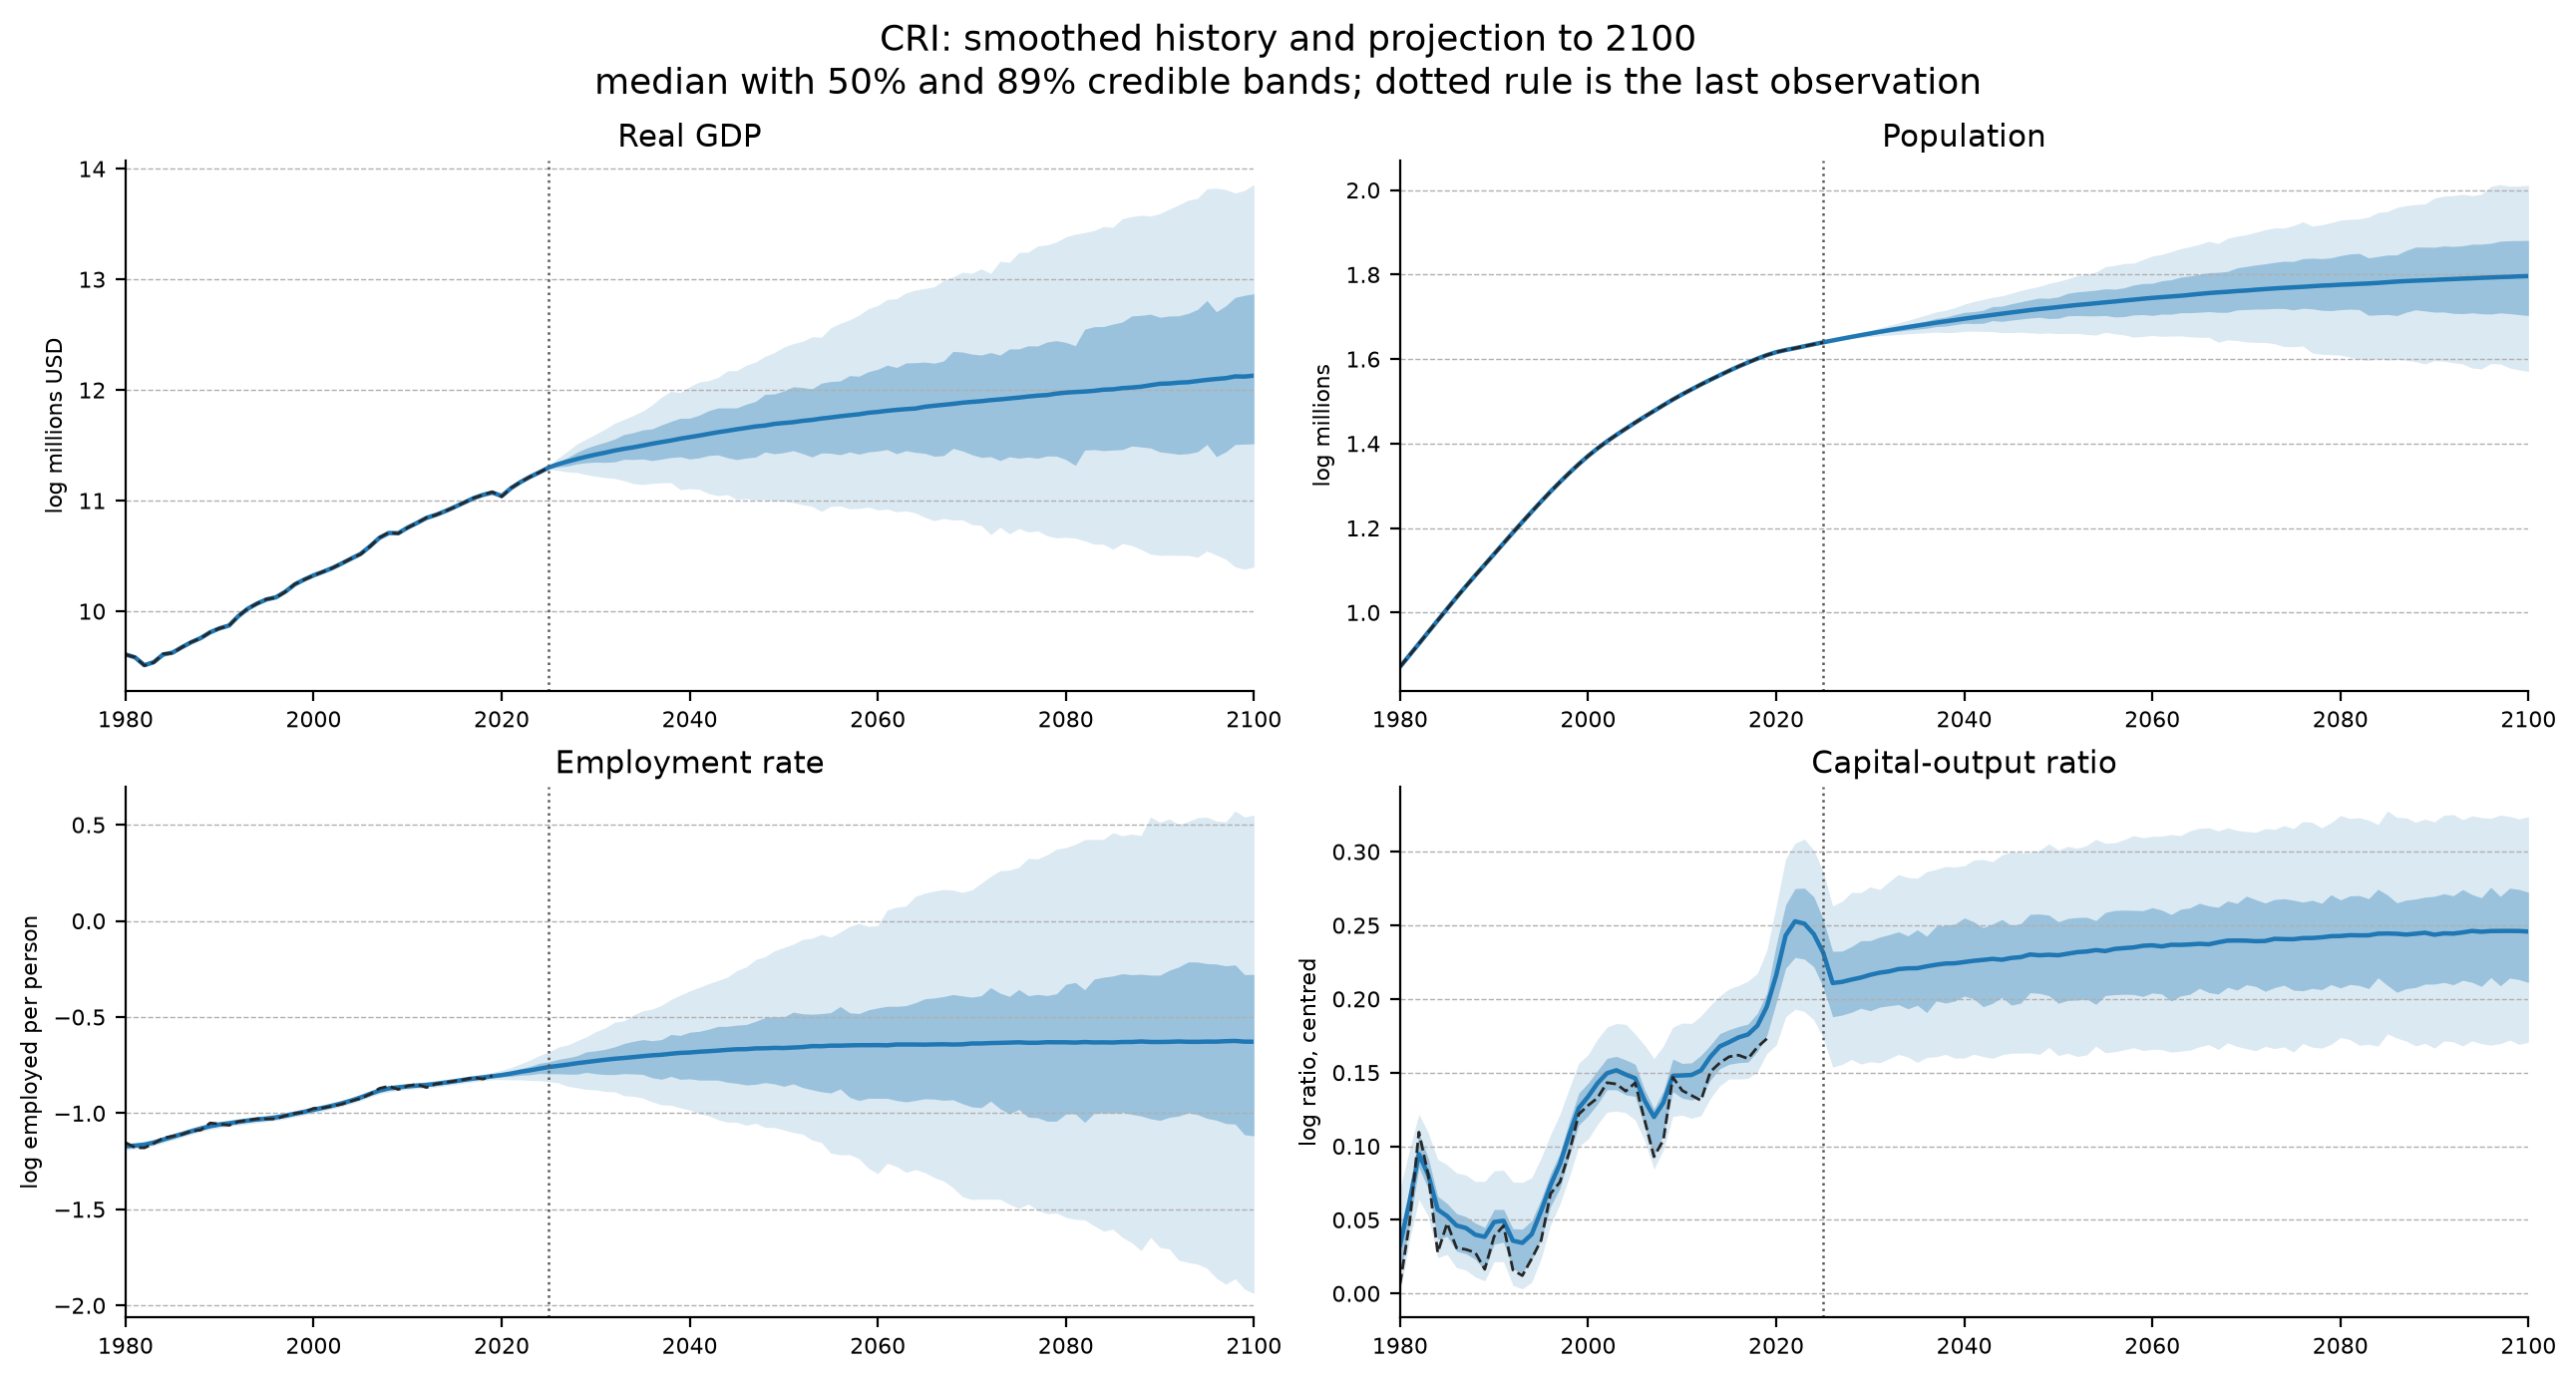

In [25]:
SHOWN = ["log_gdp", "log_pop", "log_emp_rate", "log_ky"]

joined = {
    name: xr.concat(
        [smoothed_observed.sel(observed_state=name), forecast_observed.sel(observed_state=name)],
        dim="time",
    )
    for name in SHOWN
}

figure, axes = panel_grid(names=SHOWN, labels=LABELS, units=AXIS_UNITS, n_cols=2, height=3.4, width=6.4)

for axis, name in zip(axes, SHOWN, strict=True):
    plot_fan(draws=joined[name], axis=axis, observed=observed[name], divider=LAST)

figure.suptitle(
    f"{COUNTRY}: smoothed history and projection to {FORECAST_END:%Y}\n"
    f"median with {BAND_PROBS[0]:.0%} and {BAND_PROBS[1]:.0%} credible bands; dotted rule is the last observation",
    size=13,
)
plt.show()

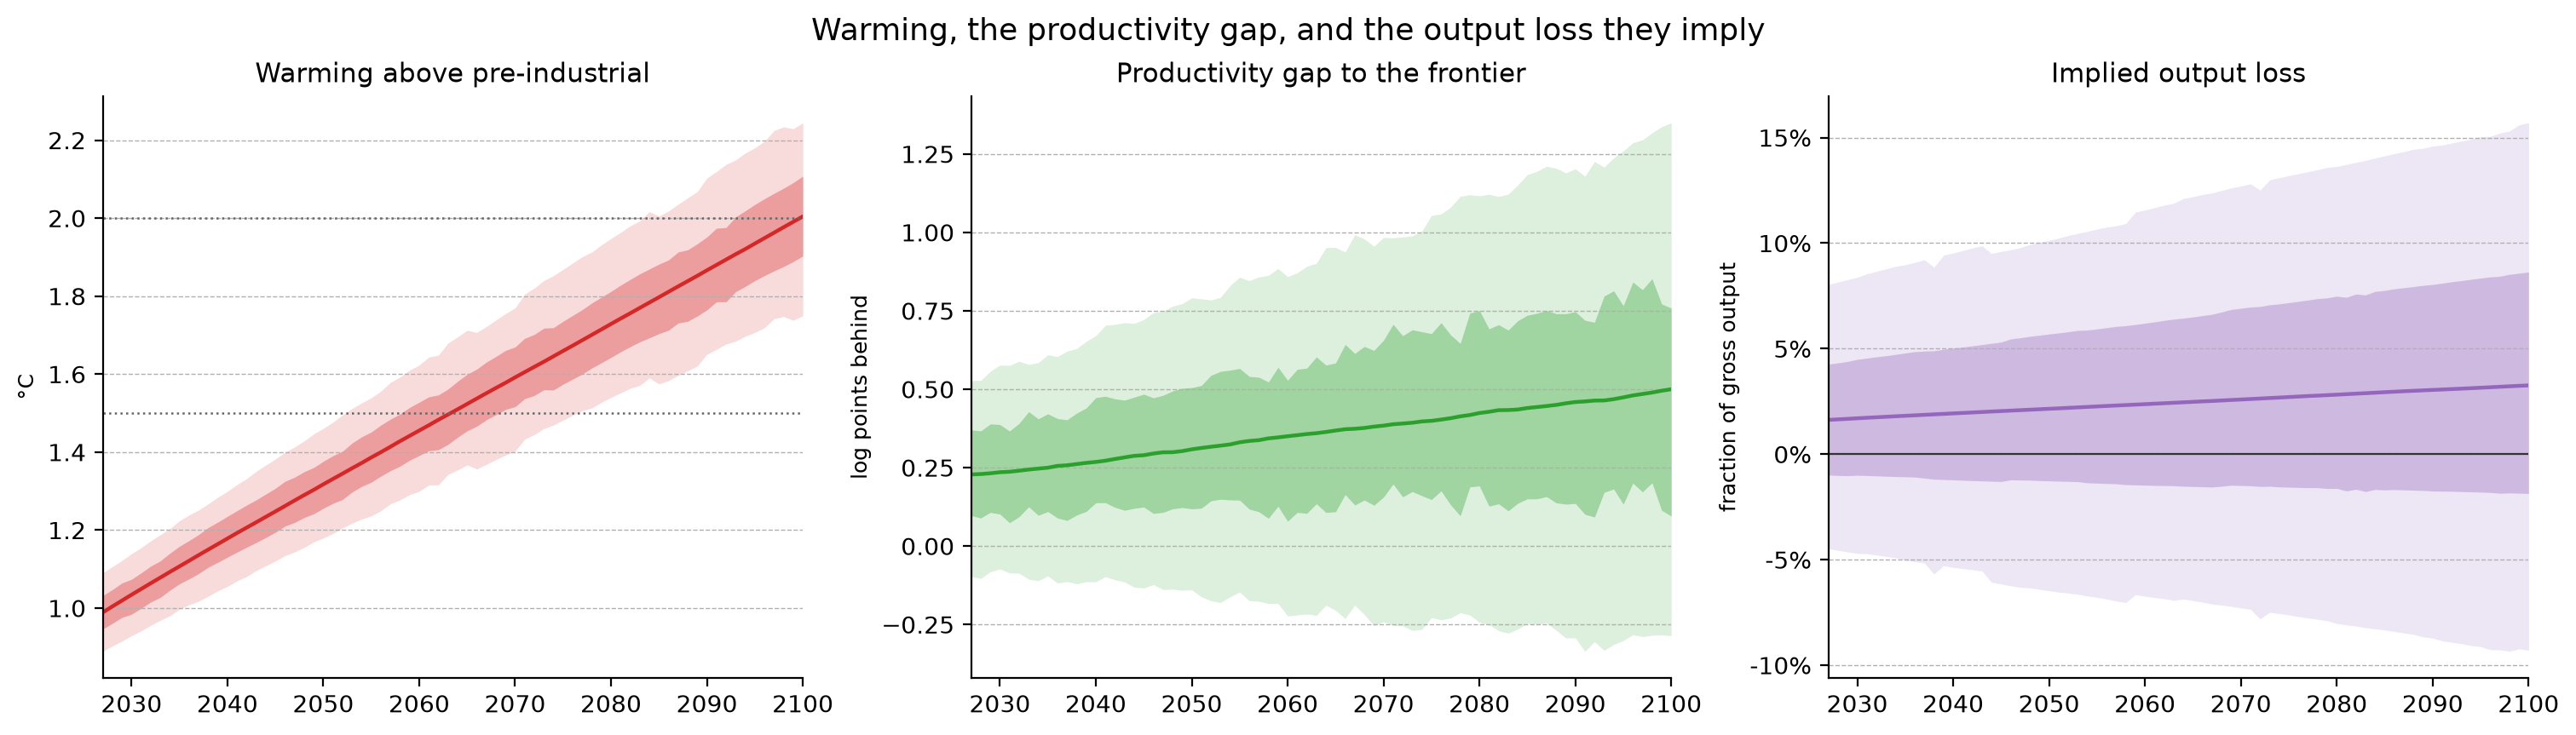

,warming °C,output loss,loss lower 89%,loss upper 89%
year,,,,
2035,1.107,0.0182,-0.0502,0.0897
2050,1.317,0.0215,-0.0647,0.1014
2075,1.659,0.0271,-0.0762,0.132
2100,2.004,0.0326,-0.0929,0.157


In [26]:
warming_ahead = forecast_latent.sel(state="warming")
gap_ahead = forecast_latent.sel(state="gap")
output_loss = 1 - np.exp(-(posterior["damage_elasticity"] * warming_ahead))

figure, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=200, layout="constrained")

plot_fan(draws=warming_ahead, axis=axes[0], color="tab:red")
for level in (1.5, 2.0):
    axes[0].axhline(level, color="0.4", ls=":", lw=0.9)
axes[0].set_title("Warming above pre-industrial", size=11, pad=6)
axes[0].set_ylabel("°C", size=9)

plot_fan(draws=gap_ahead, axis=axes[1], color="tab:green")
axes[1].set_title("Productivity gap to the frontier", size=11, pad=6)
axes[1].set_ylabel("log points behind", size=9)

plot_fan(draws=output_loss, axis=axes[2], color="tab:purple")
axes[2].axhline(0.0, color="0.2", lw=0.8)
axes[2].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[2].set_title("Implied output loss", size=11, pad=6)
axes[2].set_ylabel("fraction of gross output", size=9)

figure.suptitle("Warming, the productivity gap, and the output loss they imply", size=13)
plt.show()

summary = pd.DataFrame(
    {
        "warming °C": [float(warming_ahead.isel(time=h - 1).median(dim=["chain", "draw"])) for h in HORIZONS],
        "output loss": [float(output_loss.isel(time=h - 1).median(dim=["chain", "draw"])) for h in HORIZONS],
        "loss lower 89%": [
            float(az.hdi(output_loss.isel(time=h - 1), prob=0.89).sel(ci_bound="lower")) for h in HORIZONS
        ],
        "loss upper 89%": [
            float(az.hdi(output_loss.isel(time=h - 1), prob=0.89).sel(ci_bound="upper")) for h in HORIZONS
        ],
    },
    index=pd.Index([DATA_END.year + h for h in HORIZONS], name="year"),
)
summary.round(4)

## Against the IPCC scenarios

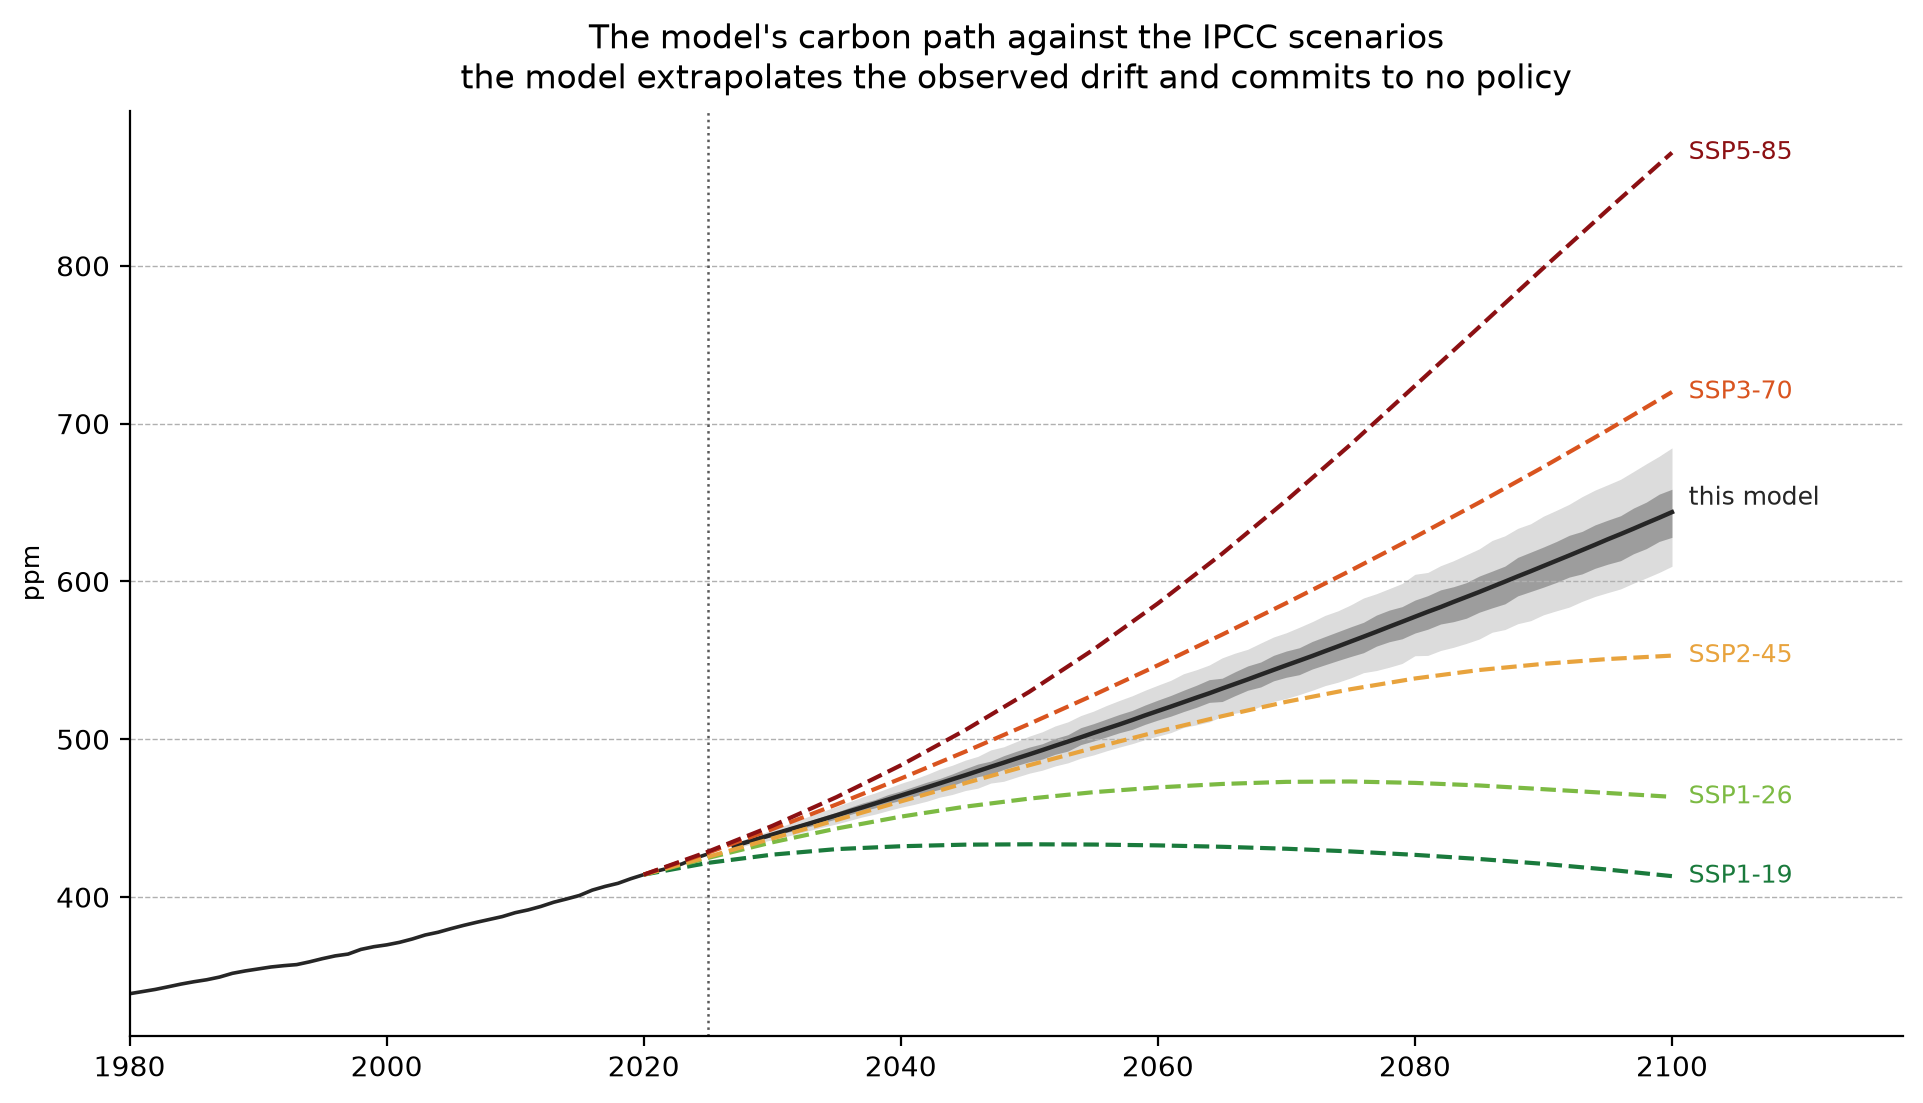

In [27]:
SSP_COLOURS = {
    "SSP1-19": "#1a7a3c",
    "SSP1-26": "#7cba43",
    "SSP2-45": "#e8a33d",
    "SSP3-70": "#d9541f",
    "SSP5-85": "#8c1013",
}
TICK_YEARS = range(1980, 2101, 20)

scenarios = process_ipcc_scenarios(CACHE_DIR).to_pandas().set_index("year")
if not isinstance(scenarios.index, pd.DatetimeIndex):
    scenarios.index = pd.to_datetime(scenarios.index, format="%Y")

forecast_co2 = np.exp(forecast_observed.sel(observed_state="log_co2"))
history = np.exp(observed["log_co2"].dropna())

figure, axis = plt.subplots(figsize=(9.5, 5.4), dpi=200, layout="constrained")

plot_fan(draws=forecast_co2, axis=axis, color="0.15", divider=LAST)
axis.plot(history.index, history.to_numpy(), color="0.15", lw=1.3)

median_co2 = forecast_co2.median(dim=["chain", "draw"])
labelled = [("this model", median_co2.time.values[-1], float(median_co2[-1]), "0.15", 5)]

for name, colour in SSP_COLOURS.items():
    series = scenarios[name].dropna().loc[:FORECAST_END]
    axis.plot(series.index, series.to_numpy(), color=colour, lw=1.5, ls="--")
    labelled.append((name, series.index[-1], float(series.iloc[-1]), colour, 0))

for text, when, level, colour, nudge in labelled:
    axis.annotate(
        text,
        xy=(when, level),
        xytext=(6, nudge),
        textcoords="offset points",
        color=colour,
        size=9,
        va="center",
    )

axis.set_xlim(history.index[0], FORECAST_END + pd.DateOffset(years=18))
axis.set_xticks(pd.to_datetime([str(year) for year in TICK_YEARS]))
axis.set_xticklabels([str(year) for year in TICK_YEARS])
axis.set_ylabel("ppm", size=9)
axis.set_title(
    "The model's carbon path against the IPCC scenarios\n"
    "the model extrapolates the observed drift and commits to no policy",
    size=12,
    pad=8,
)
plt.show()